#  Исследование результатов А/В-теста и поиск инсайтов

### Данные

Вы будете работать с двумя датасетами:  

1. Датасет `/datasets/pa_sollmafin_hist.csv` содержит исторические данные о ключевых действиях новых пользователей, привлечённых в период с 1 апреля по 1 июня 2025 года включительно. В датасете собраны действия пользователей до оформления второго депозита.
2. Датасет `/datasets/pa_sollmafin_abt.csv` содержит данные А/В-эксперимента — все действия новых пользователей, которые зарегистрировались со 2 по 15 июня 2025 года включительно. Данные собраны в рамках проверки гипотезы о влиянии нового онбординга на поведение и активность пользователей. Пользователи уже распределены по группам А/В-эксперимента.

Общие поля датасетов:
- `user_id` — уникальный идентификатор пользователя;
- `country_code` — код страны пользователя в формате ISO (например, `BR` — Бразилия, `MX` — Мексика, `AR` — Аргентина, `CO` — Колумбия);
- `platform` — устройство, с которого пользователь взаимодействует с продуктом: mobile или web;
- `first_ts` — время первого появления пользователя в системе;
- `first_dt` — дата первого появления пользователя (без времени);
- `event_ts` — время события;
- `event_name` — название события;
- `amount` — сумма пополнения депозита;
- `asset` — тип приобретённого актива;
- `risk_level` — уровень риска актива: low — низкий риск, medium — средний риск, high — высокий риск.

В датасете `/datasets/pa_sollmafin_abt.csv` содержатся два дополнительных поля:
- `ab_test` — название А/В-эксперимента;
- `group` — пользовательская группа А/В-эксперимента.


### План проекта
1. Загрузка исторических данных и их предобработка
2. Исследовательский анализ исторических данных
3. Исследование результатов А/В эксперимента
4. Анализ изменений суммы депозитов на платящего пользователя
5. Выводы

---

## Часть 1

### 1. Загрузка исторических данных и их предобработка


In [ ]:
import pandas as pd
# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind
from scipy import stats

In [ ]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/pa_sollmafin_hist.csv', parse_dates=['first_ts','first_dt', 'event_ts'])

# Выводим на экран размер исходных таблиц
display(df.head(5))
display(df.info())

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
0,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:51,install / open_web,NaN,NaN,NaN
1,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:59,introduction,NaN,NaN,NaN
2,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:06,registration,NaN,NaN,NaN
3,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:15,main_page,NaN,NaN,NaN
4,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:47:59,onboarding_complete,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238059 entries, 0 to 238058
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       238059 non-null  object        
 1   country_code  238059 non-null  object        
 2   platform      238059 non-null  object        
 3   first_ts      238059 non-null  datetime64[ns]
 4   first_dt      238059 non-null  datetime64[ns]
 5   event_ts      238059 non-null  datetime64[ns]
 6   event_name    238059 non-null  object        
 7   amount        33093 non-null   float64       
 8   asset         15392 non-null   object        
 9   risk_level    15392 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(6)
memory usage: 18.2+ MB


None

В таблице столбцы `amount`,`asset`,`risk_level` заполнены не все данные т.к. не все пользователи пополняют депозиты и в таблице задваеваются user_id по несколько раз из-за того, что пользователь делает несколько шагов по воронке

In [ ]:
#поиск дублей
def check_double(df, name):
    print(f"=== {name} ===")
    print(f"Дубликаты: {df.duplicated().sum()}")

check_double(df, "Таблица 1")

=== Таблица 1 ===
Дубликаты: 0


Явных дублей нет

In [ ]:
#доля пропусков
def check_null(df):

    total_rows = len(df)
    null_counts = df.isnull().sum()
    null_percentage = (null_counts / total_rows * 100).round(2)

    null_summary = pd.DataFrame({
        'Доля пропусков (%)': null_percentage
    })

    print(f"Пропуски:\n{null_summary}")

check_null(df)

Пропуски:
              Доля пропусков (%)
user_id                     0.00
country_code                0.00
platform                    0.00
first_ts                    0.00
first_dt                    0.00
event_ts                    0.00
event_name                  0.00
amount                     86.10
asset                      93.53
risk_level                 93.53


Видим, что у столбцов `amount`, `asset`, `risk_level` высокая доля пропусков в данных. т.к. не все пользователи пополняют депозиты и в таблице задваеваются user_id по несколько раз из-за того, что пользователь делает несколько шагов по воронке. Это связано со спецификой продукта.

In [ ]:
#проверим интервал дат first_dt
min_date = df['first_dt'].min()
max_date = df['first_dt'].max()
date_range = max_date - min_date

print(f"Минимальная дата: {min_date}")
print(f"Максимальная дата: {max_date}")
print(f"Интервал данных: {date_range.days} дней")
print(f"Период данных: с {min_date.strftime('%Y-%m-%d')} по {max_date.strftime('%Y-%m-%d')}")

Минимальная дата: 2025-04-01 00:00:00
Максимальная дата: 2025-06-01 00:00:00
Интервал данных: 61 дней
Период данных: с 2025-04-01 по 2025-06-01


In [ ]:
negative_revenue = df[df['amount'] < 0]
if len(negative_revenue) > 0:
    print(f"Найдено отрицательных значений revenue: {len(negative_revenue)}")
    df['amount'] = df['amount'].clip(lower=0)

Отрицательных значений не найдено в столбце `amount`. Данные корректны

In [ ]:
#Проверка на неявные дубли
duplicates_check = df.duplicated(subset=['user_id', 'event_ts'], keep=False)
duplicate_count = duplicates_check.sum()

print(f"Найдено неявных дубликатов (user_id + event_ts): {duplicate_count}")
print(f"Доля дубликатов: {duplicate_count/len(df)*100:.2f}%")

Найдено неявных дубликатов (user_id + event_ts): 0
Доля дубликатов: 0.00%


In [ ]:
# Проверка уникальных значений в категориальных столбцах
categorical_cols = ['country_code', 'platform', 'event_name', 'asset', 'risk_level']
for col in categorical_cols:
    if col in df.columns:
        unique_vals = df[col].nunique()
        print(f"{col}: {unique_vals} уникальных значений")
        print(f"  Значения: {df[col].unique()}")

country_code: 4 уникальных значений
  Значения: ['BR' 'AR' 'CO' 'MX']
platform: 2 уникальных значений
  Значения: ['mobile' 'web']
event_name: 8 уникальных значений
  Значения: ['install / open_web' 'introduction' 'registration' 'main_page'
 'onboarding_complete' 'first_deposit' 'asset_purchase' 'second_deposit']
asset: 3 уникальных значений
  Значения: [nan 'stock' 'option' 'crypto']
risk_level: 3 уникальных значений
  Значения: [nan 'medium' 'high' 'low']


In [ ]:
#есть ли события, произошедшие до даты первого взаимодействия с продуктом

wrong_time_events = df[df['event_ts'] < df['first_ts']]
print(f"Найдено записей: {len(wrong_time_events):,}")

Найдено записей: 0


Выводы: Данные корректны, все столбцы с правильным типом данных, в трех столбцах до 90% пропусков, но это связано  с тем, что не все пользователи вкладываются в депозиты, и в таблице задваеваются user_id по несколько раз из-за того, что пользователь делает несколько шагов по воронке.

---

### 2. Исследовательский анализ исторических данных


**Задача 2.1.** Анализ новых пользователей.
- Изучим динамику привлечения новых пользователей в приложение.

In [ ]:
total_users = df['user_id'].nunique()
print(f"Всего уникальных пользователей: {total_users:}")

Всего уникальных пользователей: 41032


In [ ]:
#по дням
daily_users = df.groupby('first_dt')['user_id'].nunique().reset_index()
daily_users.columns = ['date', 'new_users']
daily_users['date'] = pd.to_datetime(daily_users['date'])

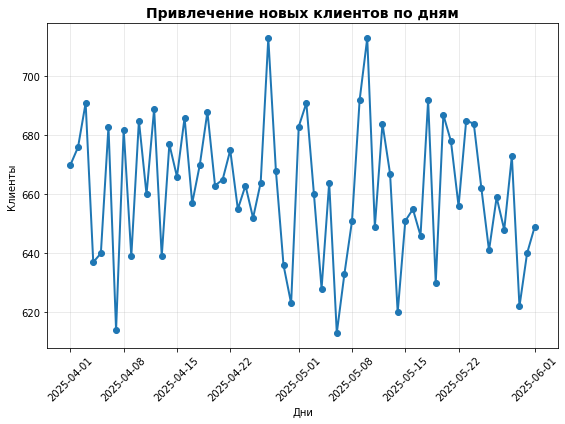

In [ ]:
#по дням
plt.figure(figsize=(8, 6))
plt.plot(daily_users['date'], daily_users['new_users'],
marker='o', linewidth=2, markersize=6)
plt.title('Привлечение новых клиентов по дням', fontsize=14, fontweight='bold')
plt.xlabel('Дни')
plt.ylabel('Клиенты')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

В исторических данных пользователи регистрировались вначале более активно и равномерно, чем в начале мая, где наблюдаются скачки в привлечении, с сильным ростом и заметным падением по дням.

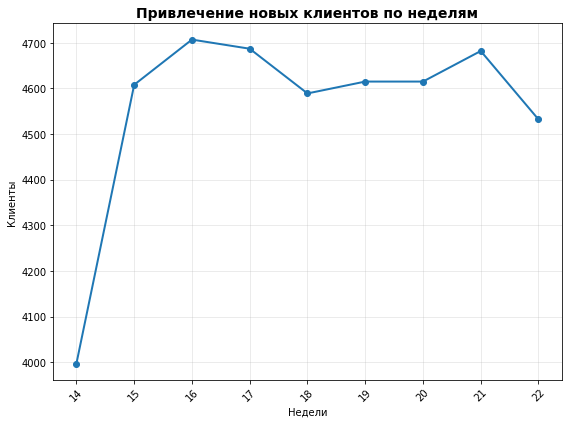

In [ ]:
#по неделям
daily_users['week_number'] = daily_users['date'].dt.isocalendar().week


weekly_users = daily_users.groupby('week_number').agg({
    'new_users': 'sum',
    'date': 'first'
}).reset_index()

plt.figure(figsize=(8, 6))
plt.plot(weekly_users['week_number'], weekly_users['new_users'],
marker='o', linewidth=2, markersize=6)
plt.title('Привлечение новых клиентов по неделям', fontsize=14, fontweight='bold')
plt.xlabel('Недели')
plt.ylabel('Клиенты')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Видно, что даже из-за скачков привлечения пользователей по дням - это не так заметно и не отражается на графике по неделям. Пользователи привлекаются из недели в неделю стабильно.

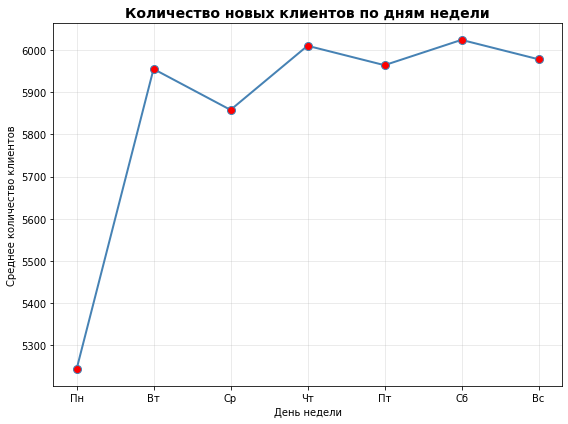

In [ ]:
# Добавляем день недели
daily_users['day_of_week'] = daily_users['date'].dt.dayofweek

weekday_agg = daily_users.groupby('day_of_week')['new_users'].sum().reset_index()
weekday_agg = weekday_agg.sort_values('day_of_week')

day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
weekday_agg['day_name'] = day_names

# Визуализация
plt.figure(figsize=(8, 6))
plt.plot(weekday_agg['day_name'], weekday_agg['new_users'],
         marker='o', linewidth=2, markersize=8, color='steelblue', markerfacecolor='red')

plt.title('Количество новых клиентов по дням недели', fontsize=14, fontweight='bold')
plt.xlabel('День недели')
plt.ylabel('Среднее количество клиентов')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Рассмотрим трафик по сегментам: платформы и страны

In [ ]:
#по платформам
platform = df.groupby('platform')['user_id'].nunique()
total_users = df['user_id'].nunique()

print(f"Распределение по платформам:")
for platform, count in platform.items():
    percentage = (count / total_users) * 100
    print(f"  {platform}: {count:} пользователей ({percentage:.1f}%)")

Распределение по платформам:
  mobile: 28758 пользователей (70.1%)
  web: 12274 пользователей (29.9%)


70% пользователей регистрировались через смартфон, хотя это мобильное приложение, но почти 30% заходили через веб-версию. Возможно, связано с возрастом клиента, старшее поколение или маркой телефона, который имеет меньшую память или слабую батарею. Возможно, что им удобнее заходить через веб и искать какую-то информацию.

In [ ]:
#по странам
country_dist = df.groupby('country_code')['user_id'].nunique()
total_users = df['user_id'].nunique()

print(f"Распределение по странам:")
for сountry, count in country_dist.items():
    percentage = (count / total_users) * 100
    print(f"  {сountry}: {count:} пользователей ({percentage:.1f}%)")

Распределение по странам:
  AR: 7489 пользователей (18.3%)
  BR: 12266 пользователей (29.9%)
  CO: 9974 пользователей (24.3%)
  MX: 11303 пользователей (27.5%)


Распределение по странам почти равномерное, отличается только Аргентина, меньше всего пользователей

In [ ]:
#по уровню риска активов
risk_dist = df.groupby('risk_level')['user_id'].nunique()

print(f"Распределение по уровню риска активов:")
for risk, count in risk_dist.items():
    print(f"  {risk}: {count:} пользователей")

Распределение по уровню риска активов:
  high: 7740 пользователей
  low: 2327 пользователей
  medium: 5325 пользователей


Пользователи активно покупают активы с высоким риском и среднем, видимо, реагируя на высокую доходность в короткие сроки. Акитвы с низким уровнем риска менее всего инересуют пользователей.

In [ ]:
#по типу приобретенного актива
asset_dist = df.groupby('asset')['user_id'].nunique()

print(f"Распределение по типу приобретенного актива:")
for risk, count in asset_dist.items():
    print(f"{risk}: {count:} пользователей")

Распределение по типу приобретенного актива:
crypto: 5040 пользователей
option: 5189 пользователей
stock: 5163 пользователей


Тип актива равномерно распределен между пользователями.

In [ ]:
#динамика новых пользователей по платформам (web / mobile)

daily_users_pl = df.groupby(['first_dt', 'platform'])['user_id'].nunique().reset_index()
daily_users_pl.columns = ['date', 'platform','new_users']
daily_users_pl['date'] = pd.to_datetime(daily_users_pl['date'])

#по неделям
daily_users_pl['week_number'] = daily_users_pl['date'].dt.isocalendar().week


weekly_users_platform = daily_users_pl.groupby(['week_number', 'platform']).agg({
    'new_users': 'sum'
}).reset_index()

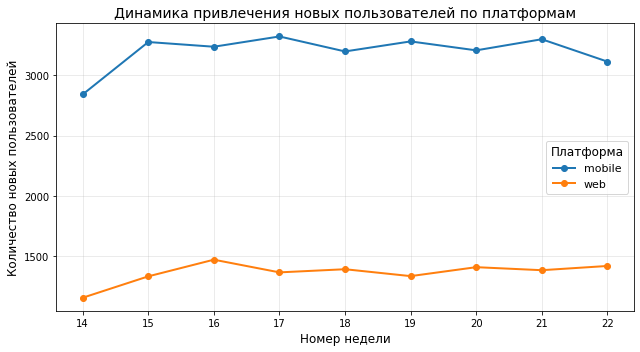

In [ ]:
# Создаем график
plt.figure(figsize=(9, 5))

# Получаем уникальные платформы и цвета
platforms = weekly_users_platform['platform'].unique()

# Строим линии для каждой платформы
for platform in platforms:
    platform_data = weekly_users_platform[weekly_users_platform['platform'] == platform]
    plt.plot(platform_data['week_number'], platform_data['new_users'],
             marker='o', linewidth=2, markersize=6, label=platform)

# Настройка графика
plt.title('Динамика привлечения новых пользователей по платформам', fontsize=14)
plt.xlabel('Номер недели', fontsize=12)
plt.ylabel('Количество новых пользователей', fontsize=12)
plt.legend(title='Платформа', fontsize=11, title_fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Показываем график
plt.show()

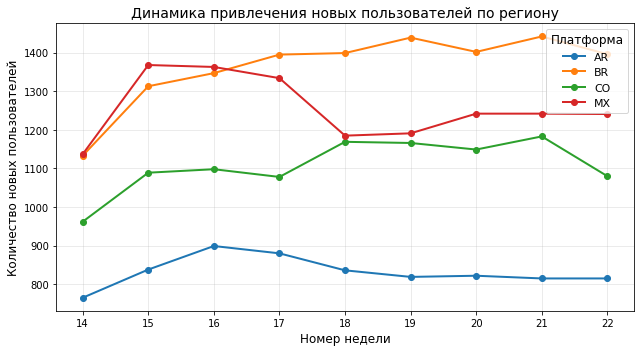

In [ ]:
#динамика новых пользователей по региону

daily_users_reg = df.groupby(['first_dt', 'country_code'])['user_id'].nunique().reset_index()
daily_users_reg.columns = ['date', 'country','new_users']
daily_users_reg['date'] = pd.to_datetime(daily_users_reg['date'])

#по неделям
daily_users_reg['week_number'] = daily_users_reg['date'].dt.isocalendar().week


weekly_users_regions = daily_users_reg.groupby(['week_number', 'country']).agg({
    'new_users': 'sum'
}).reset_index()

# Создаем график
plt.figure(figsize=(9, 5))

# Получаем уникальные платформы и цвета
countries = weekly_users_regions['country'].unique()

# Строим линии для каждой платформы
for country in countries:
    platform_data = weekly_users_regions[weekly_users_regions['country'] == country]
    plt.plot(platform_data['week_number'], platform_data['new_users'],
             marker='o', linewidth=2, markersize=6, label=country)

# Настройка графика
plt.title('Динамика привлечения новых пользователей по региону', fontsize=14)
plt.xlabel('Номер недели', fontsize=12)
plt.ylabel('Количество новых пользователей', fontsize=12)
plt.legend(title='Платформа', fontsize=11, title_fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Показываем график
plt.show()

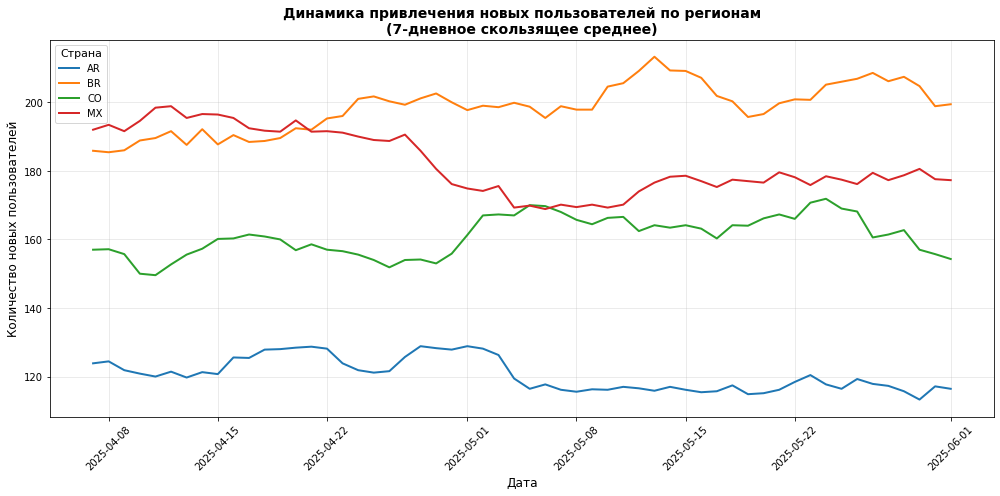

In [ ]:
# Динамика новых пользователей по региону (по дням)

daily_users_reg = df.groupby(['first_dt', 'country_code'])['user_id'].nunique().reset_index()
daily_users_reg.columns = ['date', 'country', 'new_users']
daily_users_reg['date'] = pd.to_datetime(daily_users_reg['date'])

daily_users_reg = daily_users_reg.sort_values(['country', 'date'])

#7-дневное скользящее среднее по дням
daily_users_reg['7days_rolling_avg'] = daily_users_reg.groupby('country')['new_users'] \
    .transform(lambda x: x.rolling(7).mean())

plt.figure(figsize=(14, 7))

for country in countries:
    country_data = daily_users_reg[daily_users_reg['country'] == country]

    plt.plot(country_data['date'], country_data['7days_rolling_avg'],
             linewidth=2, label=f"{country}")

plt.title('Динамика привлечения новых пользователей по регионам\n(7-дневное скользящее среднее)',
          fontsize=14, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество новых пользователей', fontsize=12)
plt.legend(title='Страна', fontsize=10, title_fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Задача 2.2.** Анализ воронок событий.
- Построим классическую и пошаговую воронки;
- Охарактеризуем пользовательский путь в приложении и определим узкие места воронки.


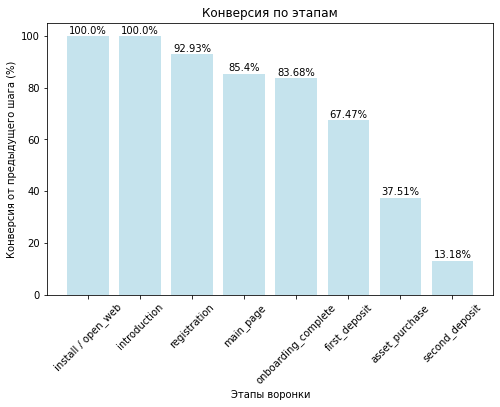

In [ ]:
#классическуая воронка — доля от первого шага в процентах
# Задаём порядок шагов в воронке
funnel_steps = ['install / open_web', 'introduction', 'registration', 'main_page', 'onboarding_complete', 'first_deposit', 'asset_purchase','second_deposit']
# Фильтруем датасет, оставляя только нужные шаги воронки
funnel_df_steps = df[df['event_name'].isin(funnel_steps)]
# Считаем число уникальных пользователей на каждом шаге
funnel_counts = funnel_df_steps.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)

# Собираем таблицу воронки
funnel_df = pd.DataFrame({
   'step': funnel_steps,
   'users': funnel_counts.values
})

funnel_df['conversion_from_first_%'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(2)


# Визуализируем данные, кроме первого шага, чтобы не выводить NaN
plt.figure(figsize=(8, 5))
# Строим barplot
# Cтроим простой график воронки
plt.bar(funnel_df['step'], funnel_df['conversion_from_first_%'], color='lightblue', alpha=0.7)

# Добавляем значения
for i, v in enumerate(funnel_df['conversion_from_first_%']):
    plt.text(i, v + 1, f'{v}%', ha='center')


plt.title('Конверсия по этапам')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)

plt.show()

Есть заметный спад на этапе перехода с `onboarding` в `first_deposit`, а также узкое место наблюдается с переходом в `asset_purchase` - более 25% не доходят до покупки актива, и почти 22% не открывают второй депозит.

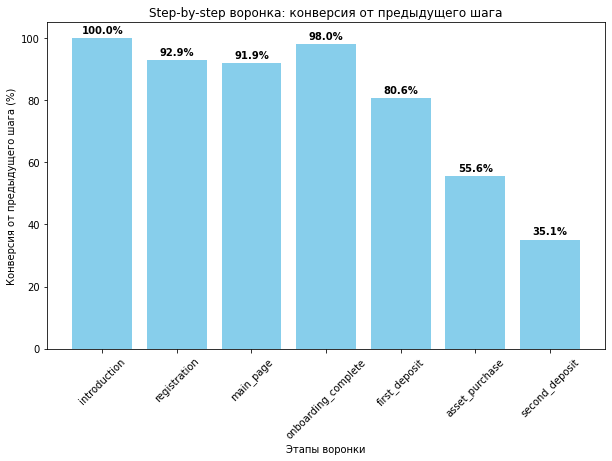

In [ ]:
#step-by-step — с конверсией от предыдущего этапа
# Задаём порядок шагов в воронке
funnel_steps = ['install / open_web', 'introduction', 'registration', 'main_page', 'onboarding_complete', 'first_deposit', 'asset_purchase','second_deposit']
# Фильтруем датасет, оставляя только нужные шаги воронки
funnel_df_steps = df[df['event_name'].isin(funnel_steps)]
# Считаем число уникальных пользователей на каждом шаге
funnel_counts = funnel_df_steps.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)

# Собираем таблицу воронки
funnel_df = pd.DataFrame({
   'step': funnel_steps,
   'users': funnel_counts.values
})

# Добавляем конверсии
funnel_df['conversion_from_previous_%'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(1)

# Визуализируем данные, кроме первого шага, чтобы не выводить NaN
plt.figure(figsize=(10, 6))
# Строим barplot
bars = plt.bar(funnel_df['step'][1:], funnel_df['conversion_from_previous_%'][1:], color='skyblue')

# Добавляем подписи значений на график
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height}%', ha='center', va='bottom', fontsize=10, fontweight='bold')


plt.title('Step-by-step воронка: конверсия от предыдущего шага')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)

plt.show()

В воронке от предыдущего шага заметны два узких места: на этапе `asset_purchase` не доходят 20% пользователей и до открытия второго депозита `second_deposit` тоже 20%. 11% пользователей не переходят с onboarding в `first_deposit`.

Классическая воронка по платформам

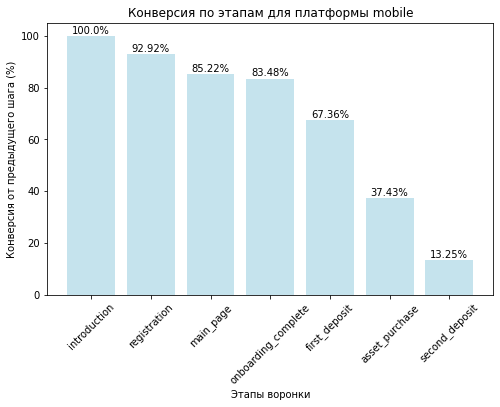

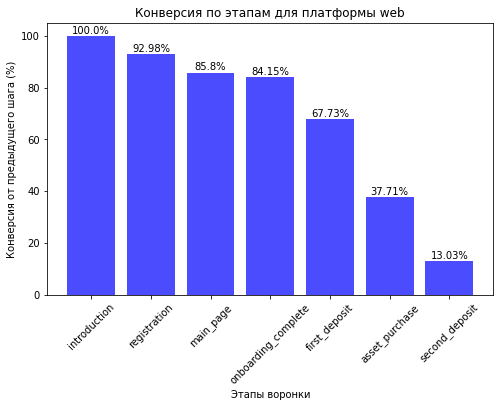

In [ ]:
#классическуая воронка — доля от первого шага в процентах
# Задаём порядок шагов в воронке
funnel_steps = ['install / open_web', 'introduction', 'registration', 'main_page', 'onboarding_complete', 'first_deposit', 'asset_purchase','second_deposit']
# Фильтруем датасет, оставляя только нужные шаги воронки
funnel_df_steps = df[df['event_name'].isin(funnel_steps)]

# Разделим данные по платформам
mobile_df = df[(df['platform'] == 'mobile')]
desktop_df = df[(df['platform'] == 'web')]

# Фильтруем датасет, оставляя только нужные шаги воронки для desktop
counts_desktop = desktop_df[desktop_df['event_name'].isin(funnel_steps)]
counts_desktop_agg = counts_desktop.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)
# Считаем конверсию для desktop и округляем значение до 1 знака после запятой

# Повторяем шаги для mobile
counts_mobile = mobile_df[mobile_df['event_name'].isin(funnel_steps)]
counts_mobile_agg = counts_mobile.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)

# Соберём через словарь данные в датафрейм и исключим первый шаг для каждого элемента
funnel_compare = pd.DataFrame({
   'step': funnel_steps[1:],
   'mobile': counts_mobile_agg[1:].round(1).values,
   'desktop': counts_desktop_agg[1:].round(1).values
})

funnel_compare['conversion_from_first_web_%'] = (funnel_compare['desktop'] / funnel_compare['desktop'].iloc[0] * 100).round(2)
funnel_compare['conversion_from_first_mob_%'] = (funnel_compare['mobile'] / funnel_compare['mobile'].iloc[0] * 100).round(2)

# Визуализируем данные, кроме первого шага, чтобы не выводить NaN
plt.figure(figsize=(8, 5))
# Строим barplot
# Cтроим простой график воронки
plt.bar(funnel_compare['step'], funnel_compare['conversion_from_first_mob_%'], color='lightblue', alpha=0.7)


# Добавляем значения
for i, v in enumerate(funnel_compare['conversion_from_first_mob_%']):
    plt.text(i, v + 1, f'{v}%', ha='center')


plt.title('Конверсия по этапам для платформы mobile')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)

plt.show()

# Визуализируем данные, кроме первого шага, чтобы не выводить NaN
plt.figure(figsize=(8, 5))
# Строим barplot
# Cтроим простой график воронки
plt.bar(funnel_compare['step'], funnel_compare['conversion_from_first_web_%'], color='blue', alpha=0.7)


# Добавляем значения
for i, v in enumerate(funnel_compare['conversion_from_first_web_%']):
    plt.text(i, v + 1, f'{v}%', ha='center')


plt.title('Конверсия по этапам для платформы web')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)

plt.show()



Воронка step-by-step по платформам

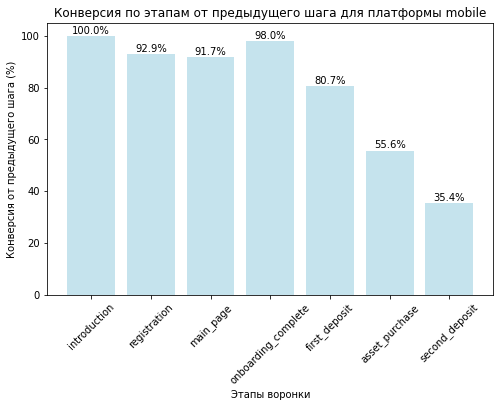

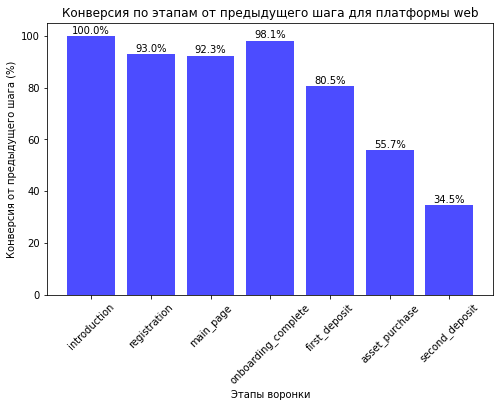

In [ ]:
#классическуая воронка — доля от первого шага в процентах
# Задаём порядок шагов в воронке
funnel_steps = ['install / open_web', 'introduction', 'registration', 'main_page', 'onboarding_complete', 'first_deposit', 'asset_purchase','second_deposit']
# Фильтруем датасет, оставляя только нужные шаги воронки
funnel_df_steps = df[df['event_name'].isin(funnel_steps)]

# Разделим данные по платформам
mobile_df = df[(df['platform'] == 'mobile')]
desktop_df = df[(df['platform'] == 'web')]

# Фильтруем датасет, оставляя только нужные шаги воронки для desktop
counts_desktop = desktop_df[desktop_df['event_name'].isin(funnel_steps)]
# Считаем количество клиентов на каждом шаге
counts_desktop_agg = counts_desktop.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)
# Считаем конверсию для desktop и округляем значение до 1 знака после запятой
desktop_funnel = (counts_desktop_agg / counts_desktop_agg.shift(1) * 100).round(1)

# Повторяем шаги для mobile
counts_mobile = mobile_df[mobile_df['event_name'].isin(funnel_steps)]
counts_mobile_agg = counts_mobile.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)
mobile_funnel = (counts_mobile_agg / counts_mobile_agg.shift(1) * 100).round(1)

# Соберём через словарь данные в датафрейм и исключим первый шаг для каждого элемента
funnel_compare = pd.DataFrame({
   'step': funnel_steps[1:],
   'mobile': mobile_funnel[1:].round(1).values,
   'desktop': desktop_funnel[1:].round(1).values
})


# Визуализируем данные, кроме первого шага, чтобы не выводить NaN
plt.figure(figsize=(8, 5))
# Строим barplot
# Cтроим простой график воронки
plt.bar(funnel_compare['step'], funnel_compare['mobile'], color='lightblue', alpha=0.7)


# Добавляем значения
for i, v in enumerate(funnel_compare['mobile']):
    plt.text(i, v + 1, f'{v}%', ha='center')


plt.title('Конверсия по этапам от предыдущего шага для платформы mobile')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)

plt.show()

# Визуализируем данные, кроме первого шага, чтобы не выводить NaN
plt.figure(figsize=(8, 5))
# Строим barplot
# Cтроим простой график воронки
plt.bar(funnel_compare['step'], funnel_compare['desktop'], color='blue', alpha=0.7)


# Добавляем значения
for i, v in enumerate(funnel_compare['desktop']):
    plt.text(i, v + 1, f'{v}%', ha='center')


plt.title('Конверсия по этапам от предыдущего шага для платформы web')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)

plt.show()

Классическуая воронка по странам

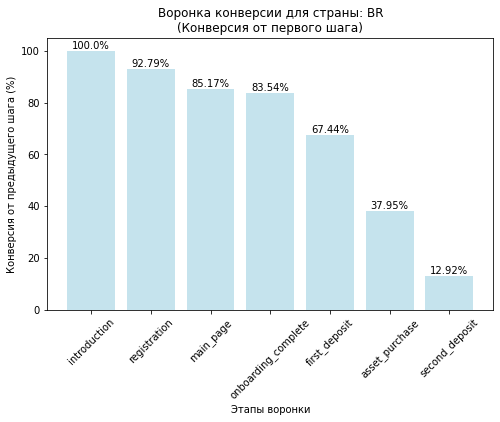

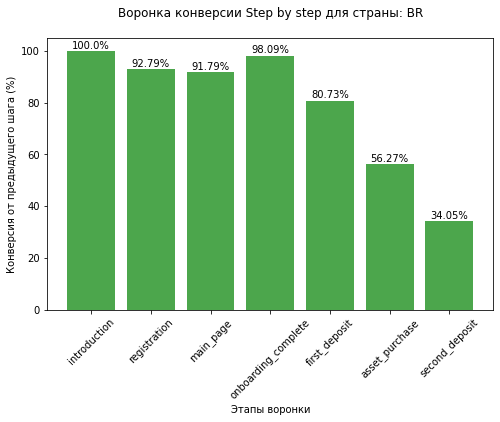

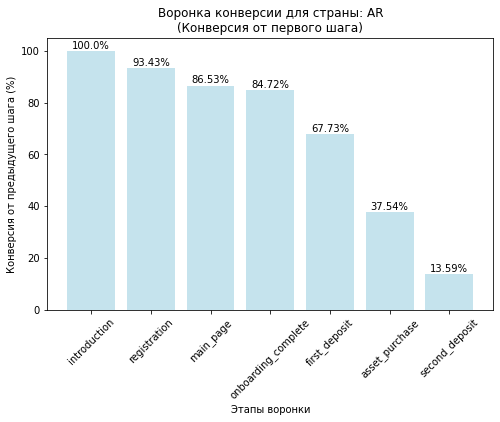

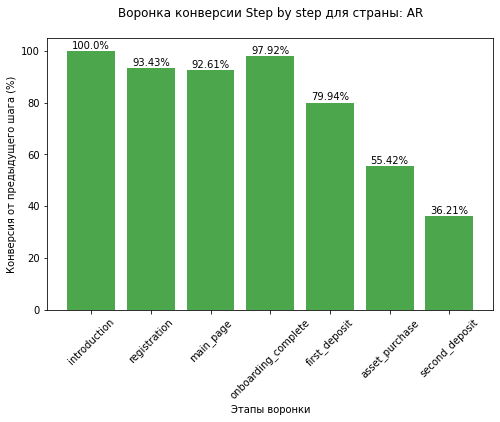

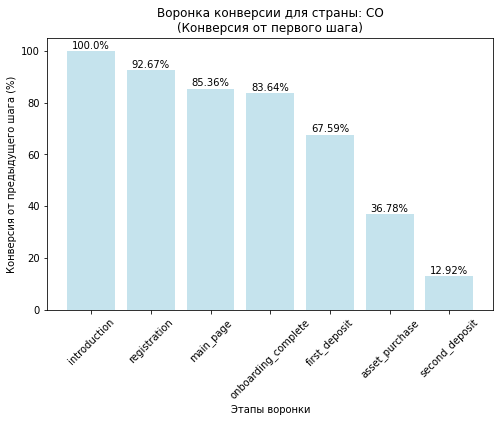

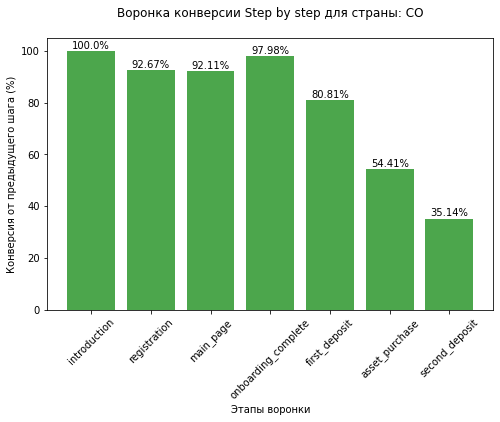

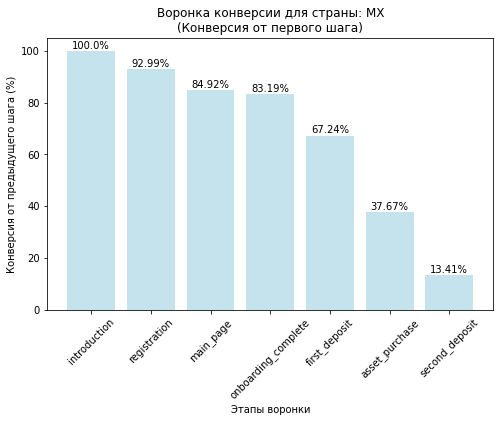

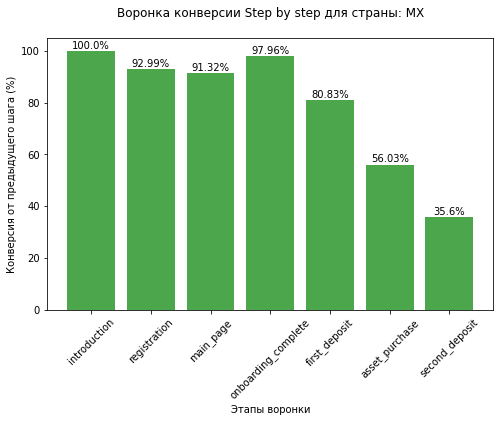

In [ ]:
#классическуая воронка — доля от первого шага в процентах
# Задаём порядок шагов в воронке
funnel_steps = ['install / open_web', 'introduction', 'registration', 'main_page', 'onboarding_complete', 'first_deposit', 'asset_purchase','second_deposit']
# Фильтруем датасет, оставляя только нужные шаги воронки
funnel_df_steps = df[df['event_name'].isin(funnel_steps)]

# Получаем список уникальных стран
countries = df['country_code'].unique()

for country in countries:
    # Фильтруем данные по стране
    country_df = df[df['country_code'] == country]
    funnel_df_steps = country_df[country_df['event_name'].isin(funnel_steps)]
    counts_agg = funnel_df_steps.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)

    # Рассчитываем конверсию от первого шага
    conversion_from_first = (counts_agg / counts_agg.iloc[0] * 100).round(2)

    # Создаем DataFrame для визуализации
    funnel_compare = pd.DataFrame({
        'step': funnel_steps[1:],
        'count': counts_agg[1:].values,
        'conversion_from_first_%': conversion_from_first[1:].values
    })

    # Визуализируем данные
    plt.figure(figsize=(8, 5))

    # Строим график воронки
    bars = plt.bar(funnel_compare['step'], funnel_compare['conversion_from_first_%'],
                   color='lightblue', alpha=0.7)

    # Добавляем значения на столбцы
    for i, v in enumerate(funnel_compare['conversion_from_first_%']):
        plt.text(i, v + 1, f'{v}%', ha='center', fontsize=10)

    plt.title(f'Воронка конверсии для страны: {country}\n(Конверсия от первого шага)')
    plt.ylabel('Конверсия от предыдущего шага (%)')
    plt.xlabel('Этапы воронки')
    plt.xticks(rotation=45)
    plt.show()

    #воронка step-by-step
    conversions = []
    for i in range(1, len(funnel_steps)):

        current_count = counts_agg.iloc[i]
        prev_count = counts_agg.iloc[i-1]

        if prev_count > 0:
            conversion_rate = (current_count / prev_count * 100).round(2)
            conversions.append({
                'step': funnel_steps[i],
                'conversion_rate_%': conversion_rate
            })

    # Создаем DataFrame для конверсий
    conversion_df = pd.DataFrame(conversions)
    # Визуализируем данные
    plt.figure(figsize=(8, 5))

    # Строим график воронки
    bars = plt.bar(conversion_df['step'], conversion_df['conversion_rate_%'],
                   color='green', alpha=0.7)

    # Добавляем значения на столбцы
    for i, v in enumerate(conversion_df['conversion_rate_%']):
        plt.text(i, v + 1, f'{v}%', ha='center', fontsize=10)

    plt.title(f'Воронка конверсии Step by step для страны: {country}\n')
    plt.ylabel('Конверсия от предыдущего шага (%)')
    plt.xlabel('Этапы воронки')
    plt.xticks(rotation=45)
    plt.show()



**Задача 2.3.** Влияние уровня риска актива на открытие второго депозита.
- Изучим, как уровень риска первого актива влияет на конверсию во второй депозит.  

asset — тип приобретённого актива;
risk_level — уровень риска актива: low — низкий риск, medium — средний риск, high — высокий риск.

In [ ]:
#Заполняем пропуски
df['risk_level_filled'] = df['risk_level'].fillna('no_risk')

#с первым депозитом
first_deposit_users = set(df[df['event_name'] == 'first_deposit']['user_id'])

#с покупкой активов
asset_purchases = df[df['event_name'] == 'asset_purchase'].copy()

#пользователи со вторым депозитом
second_deposit_users = set(df[df['event_name'] == 'second_deposit']['user_id'])

#находим первый актив
first_assets = asset_purchases.sort_values('event_ts').groupby('user_id').first().reset_index()

# Считаем конверсию по уровням риска
conversion_data = []
risk_levels = ['low', 'medium', 'high']

for risk in risk_levels:
    users_this_risk = set(first_assets[first_assets['risk_level_filled'] == risk]['user_id'])

    #сделали первый депозит
    users_with_first_deposit = users_this_risk.intersection(first_deposit_users)

    #сделали второй депозит
    users_with_second = users_with_first_deposit.intersection(second_deposit_users)

    total = len(users_with_first_deposit)
    second_deposit = len(users_with_second)


    conversion = (second_deposit / total * 100)


    conversion_data.append({
        'risk_level': risk,
        'total_users_with_first_deposit': total,
        'second_deposit': second_deposit,
        'conversion_rate': conversion
    })

conversion_df = pd.DataFrame(conversion_data).sort_values('conversion_rate', ascending=False)
display(conversion_df)

,risk_level,total_users_with_first_deposit,second_deposit,conversion_rate
0,low,2327,1080,46.411689
1,medium,5325,2288,42.967136
2,high,7740,2040,26.356589


Высокий уровень риска снижает конверсию во второй депозит примерно на 15%, по сравнению с уровнем риска low и medium.

**Задача 2.4.** Анализ ключевой метрики на исторических данных.
- На исторических данных рассчитаем значение ключевой метрики — средней суммы всех депозитов на одного пользователя.
- Визуализируйте данные, где необходимо. По результатам исследовательского анализа сделаем краткий вывод.

In [ ]:
#все события депозитов
deposit_events = df[df['amount'] > 0].copy()
print(f"Всего депозитов: {len(deposit_events):}")

#все уникальные пользователи
all_users = df['user_id'].nunique()
print(f"Всего уникальных пользователей: {all_users:}")

#общая сумма всех депозитов
total_deposits_sum = deposit_events['amount'].sum()
print(f"Общая сумма всех депозитов: {total_deposits_sum:}")

#средняя сумма депозитов на одного пользователя
avg_deposit_per_user = total_deposits_sum / all_users
print(f"Средняя сумма депозитов на пользователя с выбросами: {avg_deposit_per_user:.2f}")

Всего депозитов: 33093
Всего уникальных пользователей: 41032
Общая сумма всех депозитов: 3756981.0
Средняя сумма депозитов на пользователя с выбросами: 91.56


Большая часть пользователей вкладывают деньги, аудитория приходит целевая, им нравится приложение и они разбираются в активах. Скорее всего, кто-то вкладывает несколько раз средства.Средняя сумма депозитов на пользователя: 91.56

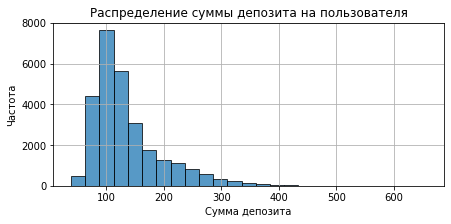

In [ ]:
#построить гистограмму и ящик с усами, посмотрим, как выглядит распределение

#Группируем по пользователям и суммируем amount
user_deposits = deposit_events.groupby('user_id')['amount'].sum().reset_index()
user_deposits.columns = ['user_id', 'total_deposit']

#Строим гистограмму с amount > 0
plt.figure(figsize=(7, 3))

user_deposits['total_deposit'].plot(
                kind='hist',
                bins=25,
                alpha=0.75,
                edgecolor='black',
                rot=0,
)

plt.title('Распределение суммы депозита на пользователя')
plt.xlabel('Сумма депозита')
plt.ylabel('Частота')
#Добавляем сетку графика
plt.grid()
#Выводим график
plt.show()

Если рассматривать пользователей, которые пополнили депозит, то это нормальное распределение с правым хвостом, т.е. есть выбросы. В основном, пользователи пополняют счет на 90-100 единиц.

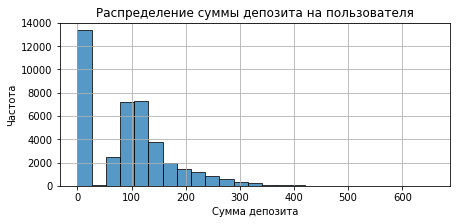

In [ ]:
#Группируем по пользователям и суммируем amount
user_deposits_all = df.groupby('user_id')['amount'].sum().reset_index()
user_deposits_all.columns = ['user_id', 'total_deposit']

#Строим гистограмму со всеми пользователями
plt.figure(figsize=(7, 3))

user_deposits_all['total_deposit'].plot(
                kind='hist',
                bins=25,
                alpha=0.75,
                edgecolor='black',
                rot=0,
)

plt.title('Распределение суммы депозита на пользователя')
plt.xlabel('Сумма депозита')
plt.ylabel('Частота')
#Добавляем сетку графика
plt.grid()
#Выводим график
plt.show()

При рассмотрении активности всех пользователей по части депозитов, то выделяется группа пользователей, которая не пополняет счет. Посчитаем процент таких пользователей - 32%

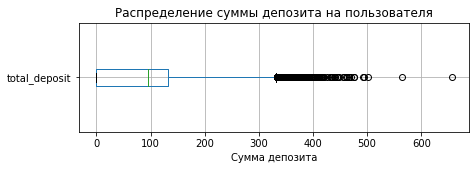

In [ ]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
user_deposits_all.boxplot(column='total_deposit', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение суммы депозита на пользователя')
plt.xlabel('Сумма депозита')

# Выводим график
plt.show()

По графику видно, что размах небольшой, и большая часть пользователей вкладывает 90-100 единиц, и наблюдается отдельная группа пользователей, которые находятся совсем правее с очень большими суммами, отдельная группа для исследования.

In [ ]:
# Для тех , кто платил по вкладу
# Определяем выбросы как значения за пределами 99% перцентилей
upper_percentile = user_deposits['total_deposit'].quantile(0.99)

outliers_percentile = user_deposits[
    (user_deposits['total_deposit'] > upper_percentile)
]

print(f"99-й перцентиль: {upper_percentile:,.2f}")
print(f"Выбросов (за пределами 99%): {len(outliers_percentile):,} ({len(outliers_percentile)/total_users*100:.1f}%)")

99-й перцентиль: 336.00
Выбросов (за пределами 99%): 270 (0.7%)


Среди пользователей, которые пополняли депозит есть небольшая группа 0.7% выбросов с суммами более 336 единиц.

In [ ]:
# Для всех
#ищем тех, кто не открывает счет - 32 перцентель
thirty_percentile = user_deposits_all['total_deposit'].quantile(0.33)
# Определяем выбросы как значения за пределами 99% перцентилей
upper_percentile = user_deposits_all['total_deposit'].quantile(0.99)

outliers_percentile = user_deposits_all[
    (user_deposits_all['total_deposit'] > upper_percentile)
]
print(f"33-й перцентиль: {thirty_percentile:,.2f}")
print(f"99-й перцентиль: {upper_percentile:,.2f}")
print(f"Выбросов (за пределами 99%): {len(outliers_percentile):,} ({len(outliers_percentile)/total_users*100:.1f}%)")

33-й перцентиль: 57.00
99-й перцентиль: 318.00
Выбросов (за пределами 99%): 407 (1.0%)


Поскольку есть выбросы в размере 1% проверим сильно ли такое значение влияет на дисперсию и среднее группы. В разрезе всех пользователей 32% не вкладывают деньги в депозит. Выбросы составляют 1% от всех пользователей с суммами от 318 единиц.

In [ ]:
# посчитаем среднее значение с округлением до 2 знаков после запятой
asset_mean = user_deposits_all.total_deposit.mean().round(2)
# посчитаем стандартное отклонение с округлением до 2 знаков после запятой
asset_std = user_deposits_all.total_deposit.std().round(2)
print(f'До удаления выбросов: среднее значение: {asset_mean} , стандартное отклонение: {asset_std}')

До удаления выбросов: среднее значение: 91.56 , стандартное отклонение: 80.39


In [ ]:
lower_percentile = user_deposits_all[
    (user_deposits_all['total_deposit'] < upper_percentile)
]
# посчитаем среднее значение с округлением до 2 знаков после запятой
asset_mean = lower_percentile.total_deposit.mean().round(2)
# посчитаем стандартное отклонение с округлением до 2 знаков после запятой
asset_std = lower_percentile.total_deposit.std().round(2)
print(f'После очистки от выбросов: среднее значение: {asset_mean} , стандартное отклонение: {asset_std}')

После очистки от выбросов: среднее значение: 88.83 , стандартное отклонение: 76.01


Среднее значение и ст.отклонение немного сместилось, на 2 п.п.. Не будем чистить данные от выбросов.

Вывод: Анализ исторических данных показывает, что продукт привлекает целевую финансово грамотную аудиторию. 68% пользователей совершают депозиты, средняя сумма вложений составляет 91.56 единицы. Продукт успешно удерживает и монетизирует аудиторию, но требует оптимизации воронки на поздних этапах для увеличения LTV.

Стабильный приток пользователей — несмотря на суточные колебания, недельная динамика привлечения стабильна.
Мобильный фокус — 70% пользователей используют смартфоны, но значительная доля (30%) предпочитает веб-версию.
Высокая конверсия в депозиты — большинство пользователей доходит до первого депозита, что говорит о целевой аудитории.
Проблемные этапы воронки — узкие места на переходах в покупку активов (20% потерь) и во второй депозит (22% потерь).Пользователи активно выбирают активы с высоким и средним риском, при этом высокий риск снижает конверсию во второй депозит на 15%.



---

## Часть 2

### 3. Исследование результатов А/В эксперимента
Загрузим данные с результатами эксперимента (датасет `/datasets/pa_sollmafin_abt.csv `). Проверим корректность данных и проведем предобработку. Зафиксируем основную информацию о данных и предобработке в кратком промежуточном выводе.
Затем проведем анализ результатов А/В-эксперимента.


In [ ]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/pa_sollmafin_abt.csv', parse_dates=['first_ts','first_dt', 'event_ts'])

# Выводим на экран размер исходных таблиц
display(df.head(5))
display(df.info())

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,ab_test,group,amount,asset,risk_level
0,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:51,install / open_web,onboarding_test,test,NaN,NaN,NaN
1,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:54,introduction,onboarding_test,test,NaN,NaN,NaN
2,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:09,registration,onboarding_test,test,NaN,NaN,NaN
3,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:13,main_page,onboarding_test,test,NaN,NaN,NaN
4,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:33:40,onboarding_complete,onboarding_test,test,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54805 entries, 0 to 54804
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       54805 non-null  object        
 1   country_code  54805 non-null  object        
 2   platform      54805 non-null  object        
 3   first_ts      54805 non-null  datetime64[ns]
 4   first_dt      54805 non-null  datetime64[ns]
 5   event_ts      54805 non-null  datetime64[ns]
 6   event_name    54805 non-null  object        
 7   ab_test       54805 non-null  object        
 8   group         54805 non-null  object        
 9   amount        7843 non-null   float64       
 10  asset         3750 non-null   object        
 11  risk_level    3750 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(8)
memory usage: 5.0+ MB


None

Всего 54805 строчки, типы данных верные, группы назначены всем пользователям, три столбца с меньшим кол-вом данных, что и понятно, из-за того, что есть дубли в столбце `user_id` и не каждый `user_id` пополняет депозит. Кол-во `amount` тоже больше, чем у `asset`. Возможно, не каждый пользоватль еще открыл депозит

In [ ]:
#поиск дублей по всем столбцам
display(f"Дубликаты: {df.duplicated().sum()}")

'Дубликаты: 0'

In [ ]:
null_percentage = (df.isna().mean() * 100).round(2)
null_percentage

user_id          0.00
country_code     0.00
platform         0.00
first_ts         0.00
first_dt         0.00
event_ts         0.00
event_name       0.00
ab_test          0.00
group            0.00
amount          85.69
asset           93.16
risk_level      93.16
dtype: float64

In [ ]:
#проверим интервал дат first_dt
min_date = df['first_dt'].min()
max_date = df['first_dt'].max()
date_range = max_date - min_date

print(f"Минимальная дата: {min_date}")
print(f"Максимальная дата: {max_date}")
print(f"Интервал данных: {date_range.days} дней")
print(f"Период данных: с {min_date.strftime('%Y-%m-%d')} по {max_date.strftime('%Y-%m-%d')}")

Минимальная дата: 2025-06-02 00:00:00
Максимальная дата: 2025-06-15 00:00:00
Интервал данных: 13 дней
Период данных: с 2025-06-02 по 2025-06-15


In [ ]:
#неявные дубли
duplicates_check = df.duplicated(subset=['user_id', 'event_ts'], keep=False)
duplicate_count = duplicates_check.sum()

print(f"Найдено неявных дубликатов (user_id + event_ts): {duplicate_count}")
print(f"Доля дубликатов: {duplicate_count/len(df)*100:.2f}%")

Найдено неявных дубликатов (user_id + event_ts): 0
Доля дубликатов: 0.00%


In [ ]:
#неявные дубли
duplicates_check = df.duplicated(subset=['user_id', 'event_name', 'event_ts'], keep=False)
duplicate_count = duplicates_check.sum()

print(f"Найдено неявных дубликатов (user_id + datetime + event): {duplicate_count}")
print(f"Доля дубликатов: {duplicate_count/len(df)*100:.2f}%")

Найдено неявных дубликатов (user_id + datetime + event): 0
Доля дубликатов: 0.00%


In [ ]:
# Проверка уникальных значений в категориальных столбцах
categorical_cols = ['country_code', 'platform', 'event_name', 'asset', 'risk_level']
for col in categorical_cols:
    if col in df.columns:
        unique_vals = df[col].nunique()
        print(f"{col}: {unique_vals} уникальных значений")
        print(f"  Значения: {df[col].unique()}")

country_code: 4 уникальных значений
  Значения: ['BR' 'MX' 'CO' 'AR']
platform: 2 уникальных значений
  Значения: ['mobile' 'web']
event_name: 8 уникальных значений
  Значения: ['install / open_web' 'introduction' 'registration' 'main_page'
 'onboarding_complete' 'first_deposit' 'asset_purchase' 'second_deposit']
asset: 3 уникальных значений
  Значения: [nan 'crypto' 'stock' 'option']
risk_level: 3 уникальных значений
  Значения: [nan 'high' 'low' 'medium']


Вывод: В данных не наблюдается явных и неявных дублей. Типы данных верны.

**Задача 3.1.** Анализ аудитории эксперимента.
- Проверим корректность распределения новых пользователей по группам А/В-эксперимента.
- Построим графики и сформулируем промежуточный вывод.

In [ ]:
#Убрать всех пользователей, которые попали сразу в несколько экспериментальных групп из таблицы

print(f"Количество пользователей до очистки: {df['user_id'].nunique()}")

df['first_ts'] = pd.to_datetime(df['first_ts'])

# Считаем кол-во уникальных групп на user_id
flawed_users = df.groupby('user_id')['group'].nunique().reset_index()
# Фильтруем клиентов у которых больше 1 группы
flawed_users = flawed_users[flawed_users['group'] > 1]

# Исключаем пользователей, которые попали в несколько групп
split_data_correct = df[~df['user_id'].isin(flawed_users['user_id'])]

# выводим текстовое сообщение 'Количество пользователей после очистки: N'
print(f"Количество пользователей после очистки: {split_data_correct['user_id'].nunique()}")

Количество пользователей до очистки: 9415
Количество пользователей после очистки: 9415


1. Задвоение записей не неблюдается в группах тестовой и контрольной.

Проверяем равномерность групп и сегментов

In [ ]:
sessions_test_group = df.groupby('group')['user_id'].nunique()
sessions_test_group

group
control    4847
test       4568
Name: user_id, dtype: int64

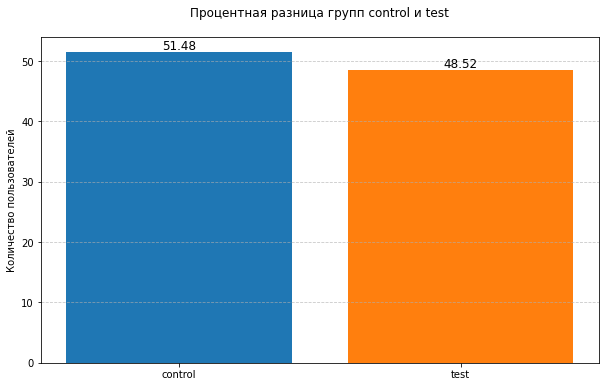

In [ ]:
plt.figure(figsize=(10, 6))

# Расчет процентов
total_users = sessions_test_group.sum()
perc_test_a = sessions_test_group['control'] / total_users * 100
perc_test_b = sessions_test_group['test'] / total_users * 100

groups = ['control', 'test']
values = [perc_test_a, perc_test_b]
colors = ['#1f77b4', '#ff7f0e']
# Синий и оранжевый

# Столбчатая диаграмма
bars = plt.bar(groups, values, color=colors)


# Настройки оформления
plt.title('Процентная разница групп control и test', pad=20)
plt.ylabel('Количество пользователей')
plt.grid(axis='y', linestyle='--', alpha=0.7)

#сверху значения
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom',
             fontsize=12)


plt.show()

**Нулевая гипотеза** Кол-во пользователей у тестовой и контрольной групп в генеральной совокупности равны <br>
**Альтернативная гипотеза**	Кол-во пользователей у тестовой и контрольной групп в генеральной совокупности не равны <br>
**Статистический критерий**	Z-тест пропорций (двухсторонний)

In [ ]:
#проверим стат.значимость разницы в группах

n_control = sessions_test_group['control']  # 4847
n_test = sessions_test_group['test']        # 4568

total_users = n_control + n_test

#Z-тест для проверки равенства пропорций

successes = [n_control, n_test]
nobs = [total_users, total_users]

#Двусторонний Z-тест
z_stat, p_value = proportions_ztest(
    successes,
    nobs,
    alternative='two-sided'
)

alpha = 0.05
print(f"  • Уровень значимости: α = {alpha}")
print(f"  • Нулевая гипотеза H₀: Доли равны")
print(f"  • Альтернативная гипотеза H₁: Доли не равны")

if p_value < alpha:
    print(f"ОТВЕРГАЕМ нулевую гипотезу (p < {alpha})")
else:
    print(f"НЕ ОТВЕРГАЕМ нулевую гипотезу (p ≥ {alpha})")

  • Уровень значимости: α = 0.05
  • Нулевая гипотеза H₀: Доли равны
  • Альтернативная гипотеза H₁: Доли не равны
ОТВЕРГАЕМ нулевую гипотезу (p < 0.05)


Разница пользователей в группах различаются на 2.98 процентных пунктов.
Контрольная группа больше тестовой на 279 пользователей (6.11%). Будем считать, что это допустимо, значение лежит в пределах нормы. Статистический тест показывает, что разница есть.

In [ ]:
# Распределение по платформам в каждой группе
print("\nРаспределение по платформам")
platform_by_group = df.groupby(['group', 'platform'])['user_id'].nunique().unstack(fill_value=0)
print(platform_by_group)


Распределение по платформам
platform  mobile   web
group                 
control     3385  1462
test        3246  1322


Равномерное распределение по платформам

In [ ]:
# Распределение по странам в каждой группе
print("\nРаспределение по платформам")
platform_by_group = df.groupby(['group', 'country_code'])['user_id'].nunique().unstack(fill_value=0)
print(platform_by_group)


Распределение по платформам
country_code   AR    BR    CO    MX
group                              
control       756  1543  1247  1301
test          725  1448  1199  1196


Равномерное распределение по странам

Построим кумулятивные графики метрик для понимания общей динамики

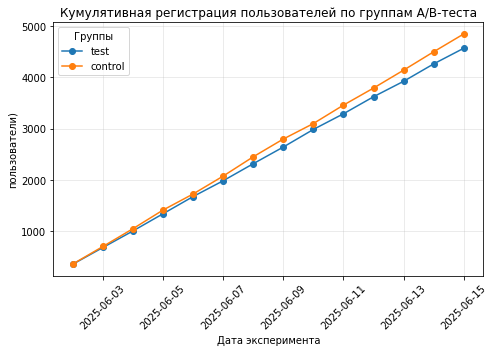

In [ ]:
# Преобразуем дату
df['event_ts'] = pd.to_datetime(df['event_ts'])
df['day_active'] = df['event_ts'].dt.date

events_filtered = df[
    (df['day_active'] >= pd.Timestamp('2025-06-02').date()) &
    (df['day_active'] <= pd.Timestamp('2025-06-15').date())
]

# Оставляем только нужные столбцы
events_with_groups = events_filtered[['user_id', 'day_active', 'group']].copy()

# Пустой список для результатов
records = []

# Расчет кумулятивного прихода пользователей
for current_date in sorted(events_with_groups['day_active'].unique()):

    # Все события до текущей даты
    active_to_date = events_with_groups[events_with_groups['day_active'] <= current_date]

    # Количество уникальных пользователей по группам
    user_counts = active_to_date.groupby('group')['user_id'].nunique().reset_index()

    user_counts['date'] = current_date
    records.append(user_counts)

# Собираем датафрейм
cumulative_df = pd.concat(records)

# Строим график
plt.figure(figsize=(7, 5))

# Создаем список уникальных групп
groups = events_with_groups['group'].unique()

# Для каждой группы строим свою линию
for group in groups:
    # Фильтруем данные по группе
    group_data = cumulative_df[cumulative_df['group'] == group]

    # Сортируем по дате для правильного построения графика
    group_data = group_data.sort_values('date')

    # Строим линию для этой группы
    plt.plot(group_data['date'], group_data['user_id'], marker='o', label=group)

# Добавляем заголовок и подписи осей
plt.title('Кумулятивная регистрация пользователей по группам A/B-теста')
plt.xlabel('Дата эксперимента')
plt.ylabel('пользователи)')

# Добавляем легенду
plt.legend(title='Группы')

# Поворачиваем подписи дат для лучшей читаемости
plt.xticks(rotation=45)

# Добавляем сетку для лучшей читаемости
plt.grid(True, alpha=0.3)

# Автоматически подгоняем layout
plt.tight_layout()

# Показываем график
plt.show()


Равномерно пользователи в группах регистрируются в приложение. Заметно небольшое увеличение кол-ва пользователей в контрольной группе с середины эксперимента.

**Задача 3.2.** Сравнение воронок событий.
- Сравним пользовательский путь новых пользователей в тестовой и контрольной группах.
- Построим классическую и последовательную воронки, выполним визуализацию и сделаем промежуточный вывод.

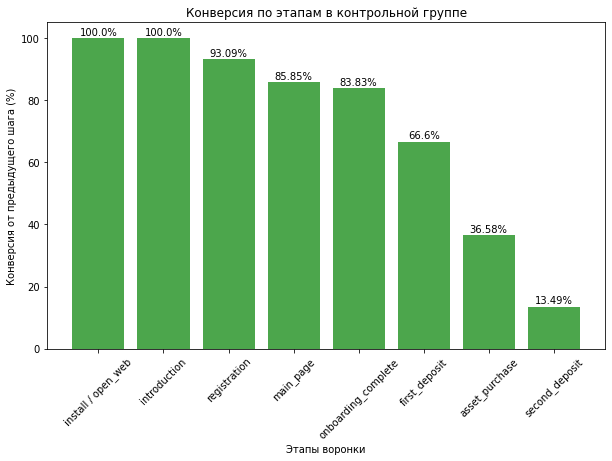

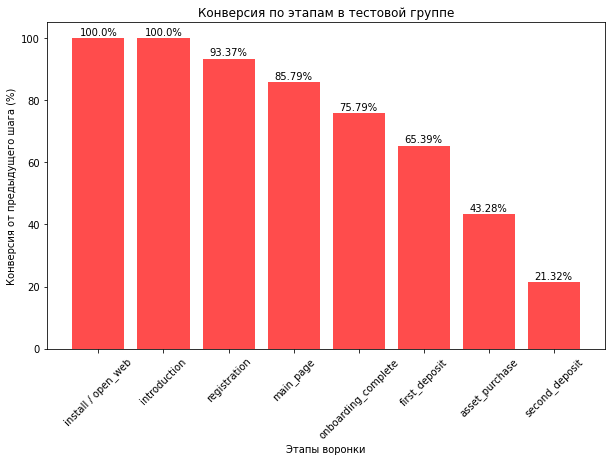

In [ ]:
#классическуая воронка — доля от первого шага в процентах

# Разделим данные по группам
control_df = df[(df['group'] == 'control')]
test_df = df[(df['group'] == 'test')]

#классическуая воронка — доля от первого шага в процентах
# Задаём порядок шагов в воронке
funnel_steps = ['install / open_web', 'introduction', 'registration', 'main_page', 'onboarding_complete', 'first_deposit', 'asset_purchase','second_deposit']
# Фильтруем датасет, оставляя только нужные шаги воронки
funnel_control_steps = control_df[control_df['event_name'].isin(funnel_steps)]
# Считаем число уникальных пользователей на каждом шаге
funnel_control_counts = funnel_control_steps.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)

# Собираем таблицу воронки
funnel_control_df = pd.DataFrame({
   'step': funnel_steps,
   'users': funnel_control_counts.values
})

funnel_control_df['conversion_from_first_%'] = (funnel_control_df['users'] / funnel_control_df['users'].iloc[0] * 100).round(2)

# Фильтруем датасет, оставляя только нужные шаги воронки
funnel_test_steps = test_df[test_df['event_name'].isin(funnel_steps)]
# Считаем число уникальных пользователей на каждом шаге
funnel_test_counts = funnel_test_steps.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)

# Собираем таблицу воронки
funnel_test_df = pd.DataFrame({
   'step': funnel_steps,
   'users': funnel_test_counts.values
})

funnel_test_df['conversion_from_first_%'] = (funnel_test_df['users'] / funnel_test_df['users'].iloc[0] * 100).round(2)

# Визуализируем данные для контрольной группы
plt.figure(figsize=(10, 6))
# Строим barplot
# Cтроим простой график воронки
plt.bar(funnel_control_df['step'], funnel_control_df['conversion_from_first_%'], color='green', alpha=0.7)

# Добавляем значения
for i, v in enumerate(funnel_control_df['conversion_from_first_%']):
    plt.text(i, v + 1, f'{v}%', ha='center')


plt.title('Конверсия по этапам в контрольной группе')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)

plt.show()

# Визуализируем данные для тестовой группы
plt.figure(figsize=(10, 6))
# Строим barplot
# Cтроим простой график воронки
plt.bar(funnel_test_df['step'], funnel_test_df['conversion_from_first_%'], color='red', alpha=0.7)

# Добавляем значения
for i, v in enumerate(funnel_test_df['conversion_from_first_%']):
    plt.text(i, v + 1, f'{v}%', ha='center')


plt.title('Конверсия по этапам в тестовой группе')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)

plt.show()

Заметно, что в контрольной группе переход к первому депозиту имеет лучший процент - 66.6% и 65.39% соответственно. В тестовой группе наблюдается низкий показатель на этапе перехода к онбординг `onboarding_complete`чем в контрольной. Возможно, что пользователей не зацепил новый вид онбординга и обучением ( потеря -10%). Зато процент покупки актива `asset_purchase` и `second_deposit` значительно выше, чем в контрольной группе.

                  step  control   test
0         introduction    100.0  100.0
1         registration     93.1   93.4
2            main_page     92.2   91.9
3  onboarding_complete     97.6   88.3
4        first_deposit     79.4   86.3
5       asset_purchase     54.9   66.2
6       second_deposit     36.9   49.3


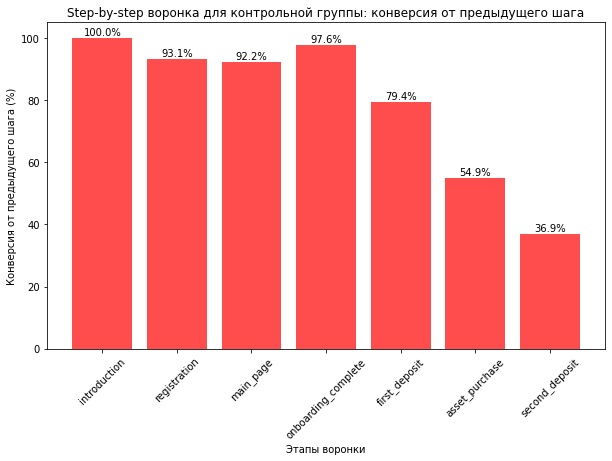

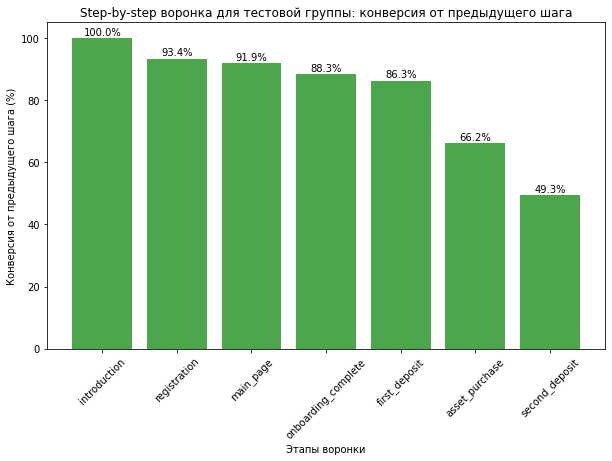

In [ ]:
# Разделим данные по группам
control_df = df[(df['group'] == 'control')]
test_df = df[(df['group'] == 'test')]

funnel_steps = ['install / open_web', 'introduction', 'registration', 'main_page', 'onboarding_complete', 'first_deposit', 'asset_purchase','second_deposit']


# Фильтруем датасет, оставляя только нужные шаги воронки для control
counts_control = control_df[control_df['event_name'].isin(funnel_steps)]
counts_control_agg = counts_control.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)
control_funnel = (counts_control_agg / counts_control_agg.shift(1) * 100).round(1)

# Повторяем шаги для test
counts_test = test_df[test_df['event_name'].isin(funnel_steps)]
counts_test_agg = counts_test.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)
test_funnel = (counts_test_agg / counts_test_agg.shift(1) * 100).round(1)

# Соберём через словарь данные в датафрейм и исключим первый шаг для каждого элемента
funnel_compare = pd.DataFrame({
   'step': funnel_steps[1:],
   'control': control_funnel[1:].round(1).values,
   'test': test_funnel[1:].round(1).values
})

print(funnel_compare.head(7))


# Визуализируем данные, кроме первого шага, чтобы не выводить NaN
plt.figure(figsize=(10, 6))
# Строим barplot
# Cтроим простой график воронки
plt.bar(funnel_compare['step'], funnel_compare['control'], color='red', alpha=0.7)

# Добавляем значения
for i, v in enumerate(funnel_compare['control']):
    plt.text(i, v + 1, f'{v}%', ha='center')


plt.title('Step-by-step воронка для контрольной группы: конверсия от предыдущего шага')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)
plt.show()

# Визуализируем данные, кроме первого шага, чтобы не выводить NaN
plt.figure(figsize=(10, 6))
# Строим barplot
# Cтроим простой график воронки
plt.bar(funnel_compare['step'], funnel_compare['test'], color='green', alpha=0.7)

# Добавляем значения
for i, v in enumerate(funnel_compare['test']):
    plt.text(i, v + 1, f'{v}%', ha='center')



plt.title('Step-by-step воронка для тестовой группы: конверсия от предыдущего шага')
plt.ylabel('Конверсия от предыдущего шага (%)')
plt.xlabel('Этапы воронки')
plt.xticks(rotation=45)
plt.show()

В воронке step-by-step в тестовой группе пользователи больше вовлекаются в процесс на этапе `onboarding_complete`, показатели в покупку актива, первого и второго депозита выше на более чем 7 п.п. чем в контрольной группе.

**Задача 3.3.** Влияние новой фичи на конверсию во второй депозит с учётом уровня риска купленного актива.
- Проанализируем, как категория риска купленного актива влияет на вероятность открытия второго депозита в тестовой и контрольной группах.
- Сравним результаты и оценим, есть ли статистически значимая разница между группами.

In [ ]:
# Разделим данные по группам
control_df = df[(df['group'] == 'control')]
test_df = df[(df['group'] == 'test')]

#находим пользователей с первым депозитом
first_deposit_users_control = control_df[control_df['event_name'] == 'first_deposit']['user_id'].unique()
asset_purchases_control = control_df[control_df['event_name'] == 'asset_purchase'].copy()
asset_users_control = asset_purchases_control['user_id'].unique()
second_deposit_users_control = control_df[control_df['event_name'] == 'second_deposit']['user_id'].unique()
first_assets_control = asset_purchases_control.sort_values('event_ts').groupby('user_id').first().reset_index()

conversion_data_cn = []
risk_levels = ['low', 'medium', 'high']

for risk in risk_levels:
    users_this_risk = set(first_assets_control[first_assets_control['risk_level'] == risk]['user_id'])

 # Из них сделали второй депозит
    users_with_second = users_this_risk.intersection(set(second_deposit_users_control))

    total = len(users_this_risk)
    second_deposit = len(users_with_second)
    conversion = (second_deposit / total * 100) if total > 0 else 0

    conversion_data_cn.append({
        'risk_level': risk,
        'total_users': total,
        'second_deposit': second_deposit,
        'conversion_rate': conversion
    })


conversion_df_control = pd.DataFrame(conversion_data_cn).sort_values('conversion_rate', ascending=False)


#находим пользователей с первым депозитом
first_deposit_users_test = test_df[test_df['event_name'] == 'first_deposit']['user_id'].unique()
asset_purchases_test = test_df[test_df['event_name'] == 'asset_purchase'].copy()
asset_users_test = asset_purchases_test['user_id'].unique()
second_deposit_users_test = test_df[test_df['event_name'] == 'second_deposit']['user_id'].unique()
first_assets_test = asset_purchases_test.sort_values('event_ts').groupby('user_id').first().reset_index()

conversion_data_test = []
risk_levels = ['low', 'medium', 'high']

for risk in risk_levels:
    users_this_risk = set(first_assets_test[first_assets_test['risk_level'] == risk]['user_id'])

 # Из них сделали второй депозит
    users_with_second = users_this_risk.intersection(set(second_deposit_users_test))

    total = len(users_this_risk)
    second_deposit = len(users_with_second)
    conversion = (second_deposit / total * 100) if total > 0 else 0

    conversion_data_test.append({
        'risk_level': risk,
        'total_users': total,
        'second_deposit': second_deposit,
        'conversion_rate': conversion
    })


conversion_df_test = pd.DataFrame(conversion_data_test).sort_values('conversion_rate', ascending=False)


In [ ]:
display("Контрольная группа", conversion_df_control)
display("Тестовая группа", conversion_df_test)

'Контрольная группа'

,risk_level,total_users,second_deposit,conversion_rate
0,low,285,142,49.824561
1,medium,595,265,44.537815
2,high,893,247,27.659574


'Тестовая группа'

,risk_level,total_users,second_deposit,conversion_rate
0,low,496,285,57.459677
1,medium,744,350,47.043011
2,high,737,339,45.997286


В тестовой группе наблюдается больший процент успешных переходов во второй депозит, особенно с активом "high", почти в два раза. С активом "low" тоже в тестовой группе есть положительные изменения, на 6 п.п.

**Нулевая гипотеза** Конверсия во второй депозит у тестовой и контрольной групп в генеральной совокупности равны <br>
**Альтернативная гипотеза**	Конверсия во второй депозит у тестовой и контрольной групп в генеральной совокупности не равны <br>
**Статистический критерий**	Z-тест пропорций с поправкой Бонферонни

In [ ]:
m = 3
alpha = 0.05
alpha_bonferroni = alpha / m # уровень значимости

# Создаём список для хранения результатов
results = []

# Уровни риска для сравнения
risk_levels = ['low', 'medium', 'high']

# Проводим попарные сравнения для каждого уровня риска
for risk in risk_levels:
    control_row = conversion_df_control[conversion_df_control['risk_level'] == risk].iloc[0]
    n_control = control_row['total_users']
    k_control = control_row['second_deposit']
    p_control = control_row['conversion_rate'] / 100

    # Извлекаем данные для тестовой группы
    test_row = conversion_df_test[conversion_df_test['risk_level'] == risk].iloc[0]
    n_test = test_row['total_users']
    k_test = test_row['second_deposit']
    p_test = test_row['conversion_rate'] / 100


# Двусторонний Z-тест
    z_stat, p_value = proportions_ztest(
        [k_control, k_test],
        [n_control, n_test],
        alternative='two-sided'
    )


    # Проверка значимости
    significant_raw = p_value < alpha
    significant_bonf = p_value < alpha_bonferroni

    results.append({
        'risk': risk,
        'p_value': f"{p_value:.5f}%",
        'significant_raw': significant_raw,
        'significant_bonf': significant_bonf
    })

# Результаты в DataFrame
import pandas as pd
results_df = pd.DataFrame(results)

print(results_df)

     risk   p_value  significant_raw  significant_bonf
0     low  0.03907%             True             False
1  medium  0.36069%            False             False
2    high  0.00000%             True              True


На основании результатов теста Z-тест пропорций с поправкой Бонферонни статистически значимой является разница в группах с активом "high".

**Задача 3.4.** Анализ метрик А/В-эксперимента. Проанализируйте такие метрики:
- Ключевая метрика — средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию).
- Барьерная метрика — конверсия из регистрации в первый депозит.
- Вспомогательная метрика 1 — конверсия из первого депозита во второй.
- Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит.

Для каждой метрики выведим:
- значения в контрольной и тестовой группах,
- абсолютные и относительные изменения значений в тестовой группе по сравнению с контрольной.

После этого проверим статистическую значимость различий метрик между группами эксперимента.

Для ключевой метрики также изучим:
- накопленную динамику изменения по дням эксперимента для каждой группы,
- стабильность p-value во время эксперимента.


**Нулевая гипотеза** Ключевая метрика — средняя сумма всех депозитов на одного пользователя у тестовой и контрольной групп в генеральной совокупности равны <br>
**Альтернативная гипотеза**	Ключевая метрика у тестовой и контрольной групп в генеральной совокупности не равны <br>
**Статистический критерий**	T-тест Уэлча (Двусторонняя)

In [ ]:
# Разделяем данные по группам
control_df = df[df['group'] == 'control']
test_df = df[df['group'] == 'test']

#Сумма всех депозитов в группе
total_deposits_control = control_df['amount'].sum()
total_deposits_test = test_df['amount'].sum()

#Количество всех пользователей в группе
total_users_control = control_df['user_id'].nunique()
total_users_test = test_df['user_id'].nunique()

#Ключевая метрика
mean1 = total_deposits_control / total_users_control
mean2 = total_deposits_test / total_users_test

def create_user_level_data(df):
    unique_user_ids = df['user_id'].unique()
    user_data = pd.DataFrame({'user_id': unique_user_ids})
    user_deposits = df.groupby('user_id')['amount'].sum().reset_index()
    user_data = user_data.merge(user_deposits, on='user_id', how='left')
    user_data['amount'] = user_data['amount'].fillna(0)
    return user_data

control_users = create_user_level_data(control_df)
test_users = create_user_level_data(test_df)

# t-тест (Welch's t-test, не предполагаем равные дисперсии)
t_stat, p_value = ttest_ind(
    control_users['amount'],
    test_users['amount'],
    equal_var=False
)


# Простая таблица только с основными метриками
results = []

results.append({
    'pvalue': p_value,
    'Mean A': mean1,
    'Mean B': mean2,
    'Absolute Lift': mean2 - mean1,
    'Relative Lift (%)': (mean2 / mean1 - 1) * 100
})

# Создаём DataFrame из результатов
results_df = pd.DataFrame(results)

# Выводим результаты
print("Результаты сравнения групп:")
print(results_df)

# Фиксируем уровень значимости
alpha = 0.05
p_value_result = results_df.iloc[0]['pvalue']

# Проверяем гипотезу
if p_value_result > alpha:
    print(f'pvalue = {p_value_result:.4f} > {alpha}')
    print('Не получилось отвергнуть нулевую гипотезу')
else:
    print(f'pvalue = {p_value_result:.4f} < {alpha}')
    print('Отвергаем нулевую гипотезу')

Результаты сравнения групп:
     pvalue     Mean A     Mean B  Absolute Lift  Relative Lift (%)
0  0.338295  90.240149  92.460814       2.220666            2.46084
pvalue = 0.3383 > 0.05
Не получилось отвергнуть нулевую гипотезу


По итогам теста Уэлча для ключевой метрики - средняя сумма всех депозитов на одного пользователя, не найдена статистически значимая разница между группами.

**Нулевая гипотеза** Барьерная метрика — конверсия из регистрации в первый депозит у тестовой и контрольной групп в генеральной совокупности равны <br>
**Альтернативная гипотеза**	Барьерная метрика у тестовой и контрольной групп в генеральной совокупности не равны <br>
**Статистический критерий**	Z-тест пропорций (двухсторонний)

In [ ]:
#Барьерная метрика — конверсия из регистрации в первый депозит - используем Z-тест пропорций
# Разделяем данные по группам
control_df = df[df['group'] == 'control']
test_df = df[df['group'] == 'test']

register_users_control = control_df[control_df['event_name'] == 'registration']['user_id'].unique()
first_deposit_users_control = control_df[control_df['event_name'] == 'first_deposit']['user_id'].unique()
#first_deposit_users_control = control_df[control_df['amount'] > 0]['user_id'].unique()

register_users_test = test_df[test_df['event_name'] == 'registration']['user_id'].unique()
first_deposit_users_test = test_df[test_df['event_name'] == 'first_deposit']['user_id'].unique()
#first_deposit_users_test = test_df[test_df['amount'] > 0]['user_id'].unique()


# Расчет конверсии
n_control = len(register_users_control)
n_test = len(register_users_test)

# Первый депозит
k_control = len(set(register_users_control).intersection(set(first_deposit_users_control)))
k_test = len(set(register_users_test).intersection(set(first_deposit_users_test)))

conversion_control = k_control / n_control * 100
conversion_test = k_test / n_test * 100

# Расчет изменений
abs_change = conversion_test - conversion_control
rel_change = (conversion_test / conversion_control - 1) * 100

z_stat, p_value = proportions_ztest(
    [k_control, k_test],
    [n_control, n_test],
    alternative='two-sided'
)

# Простая таблица только с основными метриками
results = []

results.append({
    'pvalue': p_value,
    'Conv A': conversion_control,
    'Conv B': conversion_test,
    'Absolute Lift': abs_change,
    'Relative Lift (%)': rel_change
})

# Создаём DataFrame из результатов
results_df = pd.DataFrame(results)

# Выводим результаты
print("Результаты сравнения групп:")
print(results_df)

# Фиксируем уровень значимости
alpha = 0.05
p_value_result = results_df.iloc[0]['pvalue']

# Проверяем гипотезу
if p_value_result > alpha:
    print(f'pvalue = {p_value_result:.4f} > {alpha}')
    print('Не получилось отвергнуть нулевую гипотезу')
else:
    print(f'pvalue = {p_value_result:.4f} < {alpha}')
    print('Отвергаем нулевую гипотезу')

Результаты сравнения групп:
     pvalue     Conv A    Conv B  Absolute Lift  Relative Lift (%)
0  0.120543  71.542553  70.03517      -1.507383          -2.106974
pvalue = 0.1205 > 0.05
Не получилось отвергнуть нулевую гипотезу


По итогам теста Z-тест пропорций для барьерной метрики - конверсия из регистрации в первый депозит, не найдена статистически значимая разница между группами.

**Нулевая гипотеза** Конверсия из первого депозита во второй у тестовой и контрольной групп в генеральной совокупности равны <br>
**Альтернативная гипотеза**	Вспомогательная метрика-1 у тестовой и контрольной групп в генеральной совокупности не равны <br>
**Статистический критерий**	Z-тест пропорций (двухсторонний)

In [ ]:
#Вспомогательная метрика 1 — конверсия из первого депозита во второй - - используем Z-тест пропорций

#считаем через множества
first_control_set = set(control_df[control_df['event_name'] == 'first_deposit']['user_id'])
second_control_set = set(control_df[control_df['event_name'] == 'second_deposit']['user_id'])

first_test_set = set(test_df[test_df['event_name'] == 'first_deposit']['user_id'])
second_test_set = set(test_df[test_df['event_name'] == 'second_deposit']['user_id'])

# Пользователи, которые совершили первый И второй депозит
control_first_second = first_control_set & second_control_set
test_first_second = first_test_set & second_test_set

n_control = len(first_control_set)
n_test = len(first_test_set)

k_control = len(control_first_second)
k_test = len(test_first_second)


# Расчет конверсии
conversion2_control = len(control_first_second) / len(first_control_set)
conversion2_test = len(test_first_second) / len(first_test_set)

# Абсолютное и относительное изменение
abs_change1 = conversion2_test - conversion2_control
rel_change1 = (conversion2_test / conversion2_control - 1) * 100


z_stat, p_value = proportions_ztest(
    [k_control, k_test],  # количество успехов
    [n_control, n_test],  # размеры выборок
    alternative='two-sided'
)

# Простая таблица только с основными метриками
results = []

results.append({
    'pvalue': p_value,
    'Conv A': conversion2_control,
    'Conv B': conversion2_test,
    'Absolute Lift': abs_change1,
    'Relative Lift (%)': rel_change1
})

# Создаём DataFrame из результатов
results_df = pd.DataFrame(results)

# Выводим результаты
print("Результаты сравнения групп:")
print(results_df)

# Фиксируем уровень значимости
alpha = 0.05
p_value_result = results_df.iloc[0]['pvalue']

# Проверяем гипотезу
if p_value_result > alpha:
    print(f'pvalue = {p_value_result:.4f} > {alpha}')
    print('Не получилось отвергнуть нулевую гипотезу')
else:
    print(f'pvalue = {p_value_result:.4f} < {alpha}')
    print('Отвергаем нулевую гипотезу')

Результаты сравнения групп:
         pvalue    Conv A   Conv B  Absolute Lift  Relative Lift (%)
0  1.935589e-28  0.202602  0.32608       0.123477           60.94575
pvalue = 0.0000 < 0.05
Отвергаем нулевую гипотезу


По итогам теста Z-тест пропорций для вспомогательной метрики 1 - конверсия из первого депозита во второй, найдена статистически значимая разница между группами.

**Нулевая гипотеза** Вспомогательная метрика-2 (средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит) у тестовой и контрольной групп в генеральной совокупности равны <br>
**Альтернативная гипотеза**	Вспомогательная метрика-2 у тестовой и контрольной групп в генеральной совокупности не равны <br>
**Статистический критерий**	T-тест Уэлча (Двусторонняя)

In [ ]:
#Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит

# Находим пользователей, у которых есть события депозита
users_with_deposit_control = control_df[control_df['event_name'].isin(['first_deposit', 'second_deposit'])]['user_id'].unique()
users_with_deposit_test = test_df[test_df['event_name'].isin(['first_deposit', 'second_deposit'])]['user_id'].unique()

control_users_with_deposit = control_df[control_df['user_id'].isin(users_with_deposit_control)]
test_users_with_deposit = test_df[test_df['user_id'].isin(users_with_deposit_test)]

total_deposits_control_sum = control_users_with_deposit['amount'].sum()
total_deposits_test_sum = test_users_with_deposit['amount'].sum()

total_users_with_deposit_control = len(users_with_deposit_control)
total_users_with_deposit_test = len(users_with_deposit_test)

#Вспомогательная метрика 2
mean1 = total_deposits_control_sum / total_users_with_deposit_control
mean2 = total_deposits_test_sum / total_users_with_deposit_test

def create_data_with_deposits(df):
    users_with_deposit = df[df['event_name'].isin(['first_deposit', 'second_deposit'])]['user_id'].unique()

    user_data = pd.DataFrame({'user_id': users_with_deposit})

    user_deposits = df[df['user_id'].isin(users_with_deposit)].groupby('user_id')['amount'].sum().reset_index()

    user_data = user_data.merge(user_deposits, on='user_id', how='left')
    user_data['amount'] = user_data['amount'].fillna(0)

    return user_data

# Создаем данные на уровне пользователей
control_users_deposit = create_data_with_deposits(control_df)
test_users_deposit = create_data_with_deposits(test_df)

# t-тест (Welch's t-test, не предполагаем равные дисперсии)
t_stat_2, p_value_2 = ttest_ind(
    control_users_deposit['amount'],
    test_users_deposit['amount'],
    equal_var=False
)

# Формируем результаты
results_2 = []

results_2.append({
    'pvalue': p_value_2,
    'Mean Control': mean1,
    'Mean Test': mean2,
    'Absolute Lift': mean2 - mean1,
    'Relative Lift (%)': (mean2 / mean1 - 1) * 100
})

# Создаём DataFrame из результатов
results_df_2 = pd.DataFrame(results_2)

# Выводим результаты
print("Результаты сравнения групп:")
print(results_df_2)

# Фиксируем уровень значимости
alpha = 0.05
p_value_result = results_df_2.iloc[0]['pvalue']

# Проверяем гипотезу
if p_value_result > alpha:
    print(f'pvalue = {p_value_result:.4f} > {alpha}')
    print('Не получилось отвергнуть нулевую гипотезу')
else:
    print(f'pvalue = {p_value_result:.4f} < {alpha}')
    print('Отвергаем нулевую гипотезу')

Результаты сравнения групп:
     pvalue  Mean Control   Mean Test  Absolute Lift  Relative Lift (%)
0  0.040039         135.5  141.399732       5.899732           4.354046
pvalue = 0.0400 < 0.05
Отвергаем нулевую гипотезу


По итогам теста Уэлча для вспомогательной метрики 2 - средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит, найдена статистически значимая разница между группами.

In [ ]:
#Для ключевой метрики также изучите:
#1 накопленную динамику изменения по дням эксперимента для каждой группы

# Преобразуем дату
df['event_ts'] = pd.to_datetime(df['event_ts'])
df['day_active'] = df['event_ts'].dt.date

# Разделяем данные по группам
control_df = df[df['group'] == 'control']
test_df = df[df['group'] == 'test']

# Фильтрация депозитов в пределах эксперимента
filtered_df = df[
    (df['day_active'] >= pd.Timestamp('2025-06-02').date()) &
    (df['day_active'] <= pd.Timestamp('2025-06-15').date())
]


registrations = filtered_df[filtered_df['event_name'] == 'registration'][['user_id', 'day_active']]
deposits = filtered_df[filtered_df['event_name'] == 'first_deposit'][['user_id', 'day_active']]

# Добавляем информацию о группе
registrations = registrations.merge(df[['user_id', 'group']].drop_duplicates(), on='user_id', how='left')
deposits = deposits.merge(df[['user_id', 'group']].drop_duplicates(), on='user_id', how='left')

dates = sorted(filtered_df['day_active'].unique())

records = []

for current_date in dates:
    # Все регистрации до текущей даты (включительно)
    reg_to_date = registrations[registrations['day_active'] <= current_date]

    # Все депозиты до текущей даты (включительно)
    dep_to_date = deposits[deposits['day_active'] <= current_date]

    # Уникальные пользователи с регистрацией по группам
    reg_counts = reg_to_date.groupby('group')['user_id'].nunique().reset_index()
    reg_counts.columns = ['group', 'registrations']

    # Уникальные пользователи с депозитом по группам
    dep_counts = dep_to_date.groupby('group')['user_id'].nunique().reset_index()
    dep_counts.columns = ['group', 'deposits']

    # Объединяем регистрации и депозиты по группам
    result = pd.merge(reg_counts, dep_counts, on='group', how='outer').fillna(0)

    # Расчет конверсии
    result['conversion'] = result['deposits'] / result['registrations']
    result['date'] = current_date

    records.append(result)

# Объединяем все результаты
conv_df = pd.concat(records)

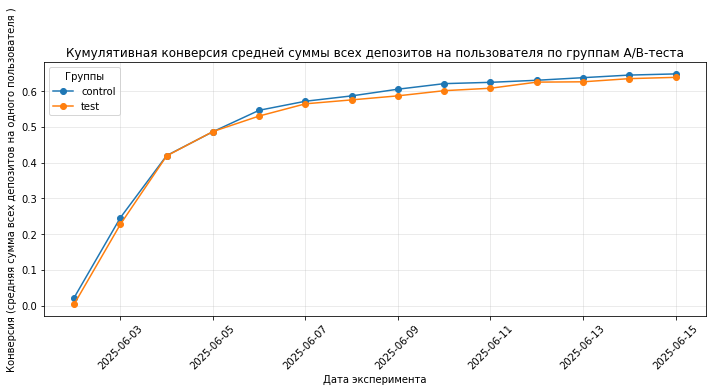

In [ ]:
# Строим график
plt.figure(figsize=(10, 5))

# Создаем список уникальных групп
groups = conv_df['group'].unique()

# Для каждой группы строим свою линию
for group in groups:
    # Фильтруем данные по группе
    group_data = conv_df[conv_df['group'] == group]

    # Сортируем по дате для правильного построения графика
    group_data = group_data.sort_values('date')

    # Строим линию для этой группы
    plt.plot(group_data['date'], group_data['conversion'], marker='o', label=group)

# Добавляем заголовок и подписи осей
plt.title('Кумулятивная конверсия средней суммы всех депозитов на пользователя по группам A/B-теста')
plt.xlabel('Дата эксперимента')
plt.ylabel('Конверсия (средняя сумма всех депозитов на одного пользователя )')

# Добавляем легенду
plt.legend(title='Группы')

# Поворачиваем подписи дат для лучшей читаемости
plt.xticks(rotation=45)

# Добавляем сетку для лучшей читаемости
plt.grid(True, alpha=0.3)

# Автоматически подгоняем layout
plt.tight_layout()

# Показываем график
plt.show()


Начиная с 2025-06-05 контрольная группа лидировала по средней сумме всех депозитов на пользователя.

При рассмотрении p-value в динамике заметна такая же тенденция, что с 2025-06-06 p-value начал расти и не понижался до стат.значимого уровня.

**Нулевая гипотеза** Ключевая метрика (средняя сумма всех депозитов на пользователя) у тестовой и контрольной групп в генеральной совокупности равны <br>
**Альтернативная гипотеза**	Ключевая метрика у тестовой и контрольной групп в генеральной совокупности не равны <br>
**Статистический критерий**	T-тест Уэлча (Двусторонняя)

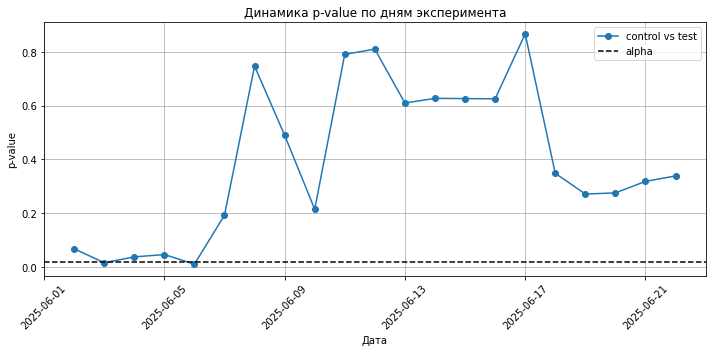

In [ ]:
# выделяем день активности
df['event_ts'] = pd.to_datetime(df['event_ts'])
df['day_active'] = df['event_ts'].dt.date

# Посчитаем сумму amount по каждой комбинации день — пользователь — группа
user_deposits = df.groupby(['day_active', 'user_id', 'group'])['amount'].sum().reset_index()

#Отсортируем список уникальных дней активности по возрастанию
user_deposits = user_deposits.sort_values('day_active')
unique_days = sorted(user_deposits['day_active'].unique())

# Список для хранения результатов
results = []


for current_date in unique_days:
    # Отфильтруем все записи до этой даты включительно (накопленные данные)
    cumulative_data = user_deposits[user_deposits['day_active'] <= current_date]

    # Посчитаем суммарную выручку на пользователя (ARPU) по группам
    user_total = cumulative_data.groupby(['user_id', 'group'])['amount'].sum().reset_index()

    # Разделяем по группам
    control_users = user_total[user_total['group'] == 'control']
    test_users = user_total[user_total['group'] == 'test']

    # Проводим t-тест между двумя группами (по распределению amount)
    t_stat, p_value = stats.ttest_ind(
            control_users['amount'].values,
            test_users['amount'].values,
            equal_var=False
        )

    results.append({
        'date': current_date,
        'p_value': p_value
    })



# Создаем DataFrame с результатами
results_df = pd.DataFrame(results)

# График
plt.figure(figsize=(10, 5))

# Построение линий графика

plt.plot(results_df['date'], results_df['p_value'],
         marker='o', label='control vs test')


plt.axhline(y=0.05/3, linestyle='--', color='black', label='alpha')
plt.title('Динамика p-value по дням эксперимента')
plt.xlabel('Дата')
plt.ylabel('p-value')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

При рассмотрении p-value в динамике заметна такая же тенденция, что с 2025-06-06 p-value начал расти и не понижался до стат.значимого уровня. С 2025-06-17 наблюдается небольшое снижение.

---

### 4. Анализ изменений суммы депозитов на платящего пользователя

Новая фича могла повлиять на поведение пользователей.


Используя бутстрап, сравните разницы перцентилей (25, 50, 75) суммы всех депозитов на платящего пользователя в контрольной и тестовой группах:
- Построим доверительные интервалы для разницы между группами для каждого перцентиля.
- Интерпретируем изменения в контексте сформулированной выше гипотезы.
- Визуализируем результат бутстрап-теста.

In [ ]:
# Рассмотрим тестовую группу
test_df = df[(df['group'] == 'test')]

#все события депозитов
deposit_events = test_df[test_df['amount'] > 0].copy()
print(f"Всего депозитов: {len(deposit_events):}")

#все уникальные пользователи
all_users = test_df['user_id'].nunique()
print(f"Всего уникальных пользователей: {all_users:}")

#общая сумма всех депозитов
total_deposits_sum = deposit_events['amount'].sum()
print(f"Общая сумма всех депозитов: {total_deposits_sum:.0f}")

#средняя сумма депозитов на одного пользователя
avg_deposit_per_user = total_deposits_sum / all_users
print(f"Средняя сумма депозитов на пользователя: {avg_deposit_per_user:.2f}")

Всего депозитов: 3961
Всего уникальных пользователей: 4568
Общая сумма всех депозитов: 422361
Средняя сумма депозитов на пользователя: 92.46


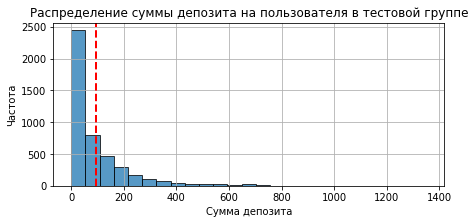

In [ ]:
test_df = df[(df['group'] == 'test')]

#построить гистограмму

# Группируем по пользователям и суммируем amount
user_deposits_test = test_df.groupby('user_id')['amount'].sum().reset_index()
user_deposits_test.columns = ['user_id', 'total_deposit']

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
user_deposits_test['total_deposit'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=25, # Устанавливаем количество корзин - всего 25
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

plt.axvline(x=avg_deposit_per_user, color='red', linestyle='--', linewidth=2)


# Настраиваем оформление графика
plt.title('Распределение суммы депозита на пользователя в тестовой группе')
plt.xlabel('Сумма депозита')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

In [ ]:
# Определяем ближайший первый вклад в тестовой группе
lower_percentile = user_deposits_test['total_deposit'].quantile(0.35)
print(f"• 35-й перцентиль тестовой группы: {lower_percentile:,.5f}")

• 35-й перцентиль тестовой группы: 25.00000


In [ ]:
# Рассмотрим контрольную группу
control_df = df[(df['group'] == 'control')]

#все события депозитов
deposit_events_control = control_df[control_df['amount'] > 0].copy()
print(f"Всего депозитов: {len(deposit_events):}")

#все уникальные пользователи
all_users = control_df['user_id'].nunique()
print(f"Всего уникальных пользователей: {all_users:}")

#общая сумма всех депозитов
total_deposits_sum = deposit_events_control['amount'].sum()
print(f"Общая сумма всех депозитов: {total_deposits_sum:.0f}")

#средняя сумма депозитов на одного пользователя
avg_deposit_per_user_c = total_deposits_sum / all_users
print(f"Средняя сумма депозитов на пользователя: {avg_deposit_per_user_c:.2f}")

Всего депозитов: 3961
Всего уникальных пользователей: 4847
Общая сумма всех депозитов: 437394
Средняя сумма депозитов на пользователя: 90.24


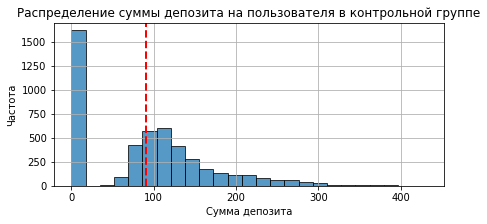

In [ ]:
#построить гистограмму контрольной группы

# Группируем по пользователям и суммируем amount
user_deposits_control = control_df.groupby('user_id')['amount'].sum().reset_index()
user_deposits_control.columns = ['user_id', 'total_deposit']

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
user_deposits_control['total_deposit'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=25, # Устанавливаем количество корзин - всего 25
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

plt.axvline(x=avg_deposit_per_user_c, color='red', linestyle='--', linewidth=2)


# Настраиваем оформление графика
plt.title('Распределение суммы депозита на пользователя в контрольной группе')
plt.xlabel('Сумма депозита')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

In [ ]:
# Определяем ближайший первый вклад в тестовой группе
lower_percentile = user_deposits_control['total_deposit'].quantile(0.34)
print(f"• 34-й перцентиль  группы: {lower_percentile:,.5f}")

• 34-й перцентиль  группы: 61.00000


Из распределения видно, что оно скошено с правым длинным хвостом, то есть присутствуют выбросы, и это типично для вкладчиков, как было исследовано на исторических данных. Красной линией обозначена средняя сумма депозита на пользователя, видно, что 25% перцентель будет с нулевыми вкладами. И только ближе к 35% перцентелю пользователи вкладывают деньги. Если сравнивать с историческими данными и контрольной группой, то там наблюдается почти такая же ситуация (с 34-перцентеля начинаются вклады). Пользователи не стали больше остерегаться вкладов.

In [ ]:
# Группируем по пользователям и суммируем amount для контрольной группы
user_deposits_c = control_df.groupby('user_id')['amount'].sum().reset_index()
user_deposits_c.columns = ['user_id', 'total_deposit']

# Группируем по пользователям и суммируем amount для тестовой группы
user_deposits_t = test_df.groupby('user_id')['amount'].sum().reset_index()
user_deposits_t.columns = ['user_id', 'total_deposit']

print("\nВсе пользователи (включая нулевые)")
print("Контрольная группа сумм всех депозитов:")
for p in [0.3,0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 0.95]:
    percentile = user_deposits_c['total_deposit'].quantile(p)
    print(f"  {int(p*100)}-й перцентиль: {percentile:.2f}")

print("\nТестовая группа сумм всех депозитов:")
for p in [0.3,0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 0.95]:
    percentile = user_deposits_t['total_deposit'].quantile(p)
    print(f"  {int(p*100)}-й перцентиль: {percentile:.2f}")


Все пользователи (включая нулевые)
Контрольная группа сумм всех депозитов:
  30-й перцентиль: 0.00
  50-й перцентиль: 95.00
  60-й перцентиль: 108.00
  70-й перцентиль: 123.00
  75-й перцентиль: 133.00
  80-й перцентиль: 145.00
  90-й перцентиль: 197.00
  95-й перцентиль: 237.00

Тестовая группа сумм всех депозитов:
  30-й перцентиль: 0.00
  50-й перцентиль: 46.00
  60-й перцентиль: 71.00
  70-й перцентиль: 104.00
  75-й перцентиль: 127.00
  80-й перцентиль: 155.00
  90-й перцентиль: 239.30
  95-й перцентиль: 342.00


При сравнении двух групп видно, что в тестовой группе люди стали более осторожными при пополнении небольших сумм, при 50-ом перцентеле в тестовой группе сумма депозита в два раза ниже, чем в контрольной. В тоже время в тестовой группе пользователи начали больше рисковать и вкладывать большие суммы, разница в с контрольной пости в полтора раза.  

In [ ]:
import pandas as pd
import numpy as np

# Разделяем данные по группам
control_df = df[df['group'] == 'control']
test_df = df[df['group'] == 'test']

# Группируем по пользователям
user_deposits_c = control_df.groupby('user_id')['amount'].sum().reset_index()
user_deposits_t = test_df.groupby('user_id')['amount'].sum().reset_index()

print("=== РАСПРЕДЕЛЕНИЕ ДЕПОЗИТОВ ===")
print("\nКонтрольная группа:")
print(f"Всего пользователей: {len(user_deposits_c)}")
print(f"Пользователей с депозитами (>0): {len(user_deposits_c[user_deposits_c['amount'] > 0])}")
print(f"Доля с депозитами: {len(user_deposits_c[user_deposits_c['amount'] > 0]) / len(user_deposits_c):.2%}")
print(f"Средняя сумма у платящих: {user_deposits_c[user_deposits_c['amount'] > 0]['amount'].mean():.2f}")

print("\nТестовая группа:")
print(f"Всего пользователей: {len(user_deposits_t)}")
print(f"Пользователей с депозитами (>0): {len(user_deposits_t[user_deposits_t['amount'] > 0])}")
print(f"Доля с депозитами: {len(user_deposits_t[user_deposits_t['amount'] > 0]) / len(user_deposits_t):.2%}")
print(f"Средняя сумма у платящих: {user_deposits_t[user_deposits_t['amount'] > 0]['amount'].mean():.2f}")

=== РАСПРЕДЕЛЕНИЕ ДЕПОЗИТОВ ===

Контрольная группа:
Всего пользователей: 4847
Пользователей с депозитами (>0): 3228
Доля с депозитами: 66.60%
Средняя сумма у платящих: 135.50

Тестовая группа:
Всего пользователей: 4568
Пользователей с депозитами (>0): 2987
Доля с депозитами: 65.39%
Средняя сумма у платящих: 141.40


В тестовой группе пользователей открывших депозит меньше, чем в контрольной, а средняя сумма чуть выше в тестовой группе за счет крупных сумм на депозитах.

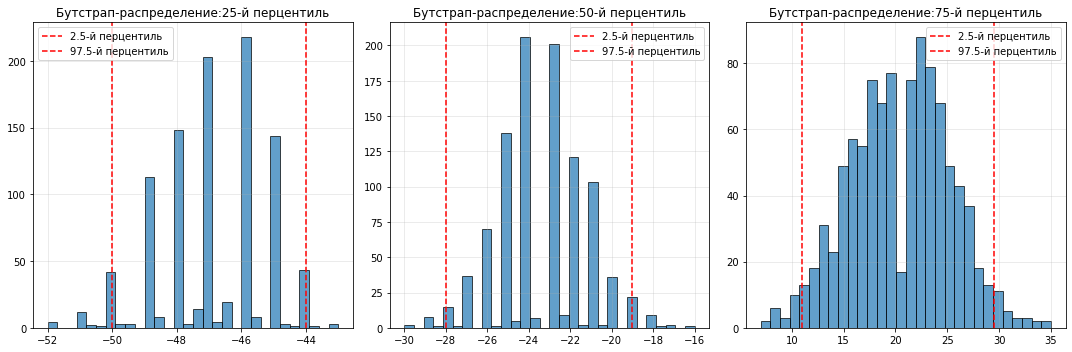

In [ ]:
# Разделяем данные по группам
control_df = df[df['group'] == 'control']
test_df = df[df['group'] == 'test']

# Группируем по пользователям и суммируем amount
user_deposits_c = control_df.groupby('user_id')['amount'].sum().reset_index()
user_deposits_t = test_df.groupby('user_id')['amount'].sum().reset_index()

# Фильтруем только платящих пользователей (сумма > 0)
paying_c = user_deposits_c[user_deposits_c['amount'] > 0]['amount'].values
paying_t = user_deposits_t[user_deposits_t['amount'] > 0]['amount'].values

# Фиксируем сид для воспроизводимости
np.random.seed(42)

n_iterations = 1000
percentiles = [25, 50, 75]

# Результаты для каждого перцентиля
results_25 = []
results_50 = []
results_75 = []

# Бутстрап-разницы перцентилей между тестовой и контрольной группами
for i in range(n_iterations):
    # Бутстрап-выборки
    boot_c = np.random.choice(paying_c, size=len(paying_c), replace=True)
    boot_t = np.random.choice(paying_t, size=len(paying_t), replace=True)

    # Расчет перцентилей и разниц
    p25_c = np.percentile(boot_c, 25)
    p25_t = np.percentile(boot_t, 25)
    results_25.append(p25_t - p25_c)

    p50_c = np.percentile(boot_c, 50)
    p50_t = np.percentile(boot_t, 50)
    results_50.append(p50_t - p50_c)

    p75_c = np.percentile(boot_c, 75)
    p75_t = np.percentile(boot_t, 75)
    results_75.append(p75_t - p75_c)

# Преобразуем в массивы
results_25 = np.array(results_25)
results_50 = np.array(results_50)
results_75 = np.array(results_75)

# Доверительные интервалы (95%)
ci_25 = np.percentile(results_25, [2.5, 97.5])
ci_50 = np.percentile(results_50, [2.5, 97.5])
ci_75 = np.percentile(results_75, [2.5, 97.5])

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 25-й перцентиль
axes[0].hist(results_25, bins=30, alpha=0.7, edgecolor='black')
axes[0].axvline(ci_25[0], color='red', linestyle='--', label='2.5-й перцентиль')
axes[0].axvline(ci_25[1], color='red', linestyle='--', label='97.5-й перцентиль')
axes[0].set_title('Бутстрап-распределение:25-й перцентиль')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 50-й перцентиль
axes[1].hist(results_50, bins=30, alpha=0.7, edgecolor='black')
axes[1].axvline(ci_50[0], color='red', linestyle='--', label='2.5-й перцентиль')
axes[1].axvline(ci_50[1], color='red', linestyle='--', label='97.5-й перцентиль')
axes[1].set_title('Бутстрап-распределение:50-й перцентиль')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 75-й перцентиль
axes[2].hist(results_75, bins=30, alpha=0.7, edgecolor='black')
axes[2].axvline(ci_75[0], color='red', linestyle='--', label='2.5-й перцентиль')
axes[2].axvline(ci_75[1], color='red', linestyle='--', label='97.5-й перцентиль')
axes[2].set_title('Бутстрап-распределение:75-й перцентиль')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Бутстрап - распределение доказывает, что статистически значимая разница между группами у 75-перцентеля, в зоне крупных сумм и выбросов. 75-перцентель тестовой группы больше, чем у контрольной. Пользователи, которые склонны к более крупным инвестициям, сильнее вовлеклись в продукт и начали вносить больше средств.

Снижение медианы может быть связано с тем, что подробный онбординг оказал сдерживающее влияние на часть пользователей со «средним» уровнем вовлечённости. Эти пользователи могли воспринять фичу как сигнал о повышенных рисках. В результате они стали реже совершать депозиты или уменьшили их объём, что и привело к снижению медианного значения.

---

### 5. Выводы

**Основные результаты, которые помогут улучшить продукт:**
1) Конверсия из первого депозита во второй значительно выросла на 12.35 п.п. (control: 20.26% vs test: 32.61%). Пользователи стали чаще возвращаться. Это важно, потому что пользователи доверяют и вкладывают больше средств.

2) Улучшение монетизации: Средняя сумма депозитов у платящих пользователей выросла на 5.9 единиц (control: 135.50 vs test: 141.40) за счет крупных депозитов. Крупные депозиты увеличивают дисперсию и средний чек, отчасти рискованы и вкладываются во второй депозит.

3) Новички стали более осторожными и меньше вкладывают средств (сейчас 32-34% с нулевыми депозитами и потери пользователей при покупке первого актива ( - 20%)). Нужно адаптировать таких юных инвесторов к онбордингу, улучшить обучение.

4) Наблюдается низкий показатель на этапе перехода к онбординг. Возможно, что пользователей не зацепил новый вид онбординга и обучением ( потеря -10%).

**Инсайты:** Улучшение онбординга повлияло на рисковых пользователей (опытных инвесторов), они начали чаще возвращаться и открывать второй депозит.


**Как новая фича повлияла на продукт:** Ключевая метрика не выросла, барьерная метрика почти не изменилась, но улучшились вспомогательные метрики. Внедрение онбординга с информацией отпугнула некоторых новичков, особенно самых осторожных, что снизило сумму депозита.

Подтверждение гипотезы: Гипотеза частично подтвердилась. Пользователи стали более осознанно подходить к инвестициям. Фича не снизила общую конверсию в первый депозит.

**Риски:** Потенциальный отток новичков. Более сложный интерфейс с подробной информацией о рисках может отпугнуть начинающих инвесторов.

Запустить фичу на всех пользователей: Новая фича повышает удержание и монетизацию, делая пользователей более вовлеченными в инвестирование. Рекомендуется запуск на всех пользователей с параллельной работой над упрощением воронки для новичков.

